In [0]:
from functools import reduce

import pandas as pd
import numpy as np
import optuna
import mlflow
from mlflow.models import infer_signature
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# PyTorch imports for deep learning - IMPORT BEFORE PYSPARK
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from pyspark.sql.functions import col
from pyspark.sql import functions as F, Window
from pyspark.sql import types as T

from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.evaluation import RegressionEvaluator


print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.6.0+cpu
CUDA available: False


In [0]:
# Configuration for large-scale data (31M rows, 350 columns)
# Cluster: 6-12 workers, m5d.4xlarge (16 vCPU, 64GB RAM per node)

USE_SAMPLE = False  # Changed from True - now using full 31M rows
SAMPLE_FRACTION = 0.01  # Not used when USE_SAMPLE=False

# Oversampling configuration (DEPRECATED - use weighted loss instead)
USE_OVERSAMPLING = False  # Set to True to balance training data (50% above log(15+1) threshold)
                          # WARNING: Increases memory by 40% and causes Spark driver errors
                          # RECOMMENDED: Use USE_WEIGHTED_LOSS instead

# Weighted loss configuration (RECOMMENDED alternative to oversampling)
USE_WEIGHTED_LOSS = False  # Set to True to emphasize high-delay predictions in loss function
                          # Benefits: No memory overhead, no Spark errors, same effectiveness

# Bias correction configuration
USE_BIAS_CORRECTION = False  # Set to True to apply bias correction when converting from log scale to original scale

In [0]:
df = spark.read.parquet("dbfs:/student-groups/Group_03_01/data_gold.parquet").repartition(64)
print(f"Dataframe has {df.count()} rows and {len(df.columns)} columns.")

Dataframe has 30512480 rows and 151 columns.


In [0]:
df = df.withColumn("YEAR_MONTH", F.concat_ws("-", F.col("YEAR"), F.col("MONTH")))
keys = [row.YEAR_MONTH for row in df.select("YEAR_MONTH").distinct().collect()]
fractions = {k: SAMPLE_FRACTION for k in keys}
data_5y_sampled = df.sampleBy("YEAR_MONTH", fractions, seed=42)

if USE_SAMPLE: 
    data = data_5y_sampled
else:
    data = df

print(data.count())

30512480


In [0]:
import requests

url = "https://raw.githubusercontent.com/bemilyz/mids261_final_project_grp3_1_2025/main/Feature_Selection%20-%20complete_num.csv"
local_tmp_path = "/tmp/Feature_Selection.csv"
dbfs_path = "dbfs:/student-groups/Group_3_1/Feature_Selection.csv"

response = requests.get(url)
with open(local_tmp_path, "wb") as f:
    f.write(response.content)

dbutils.fs.cp(
    f"file:{local_tmp_path}",
    dbfs_path
)

features_metadata = (
    spark.read.format("csv")
    .option("header", True)
    .load(dbfs_path)
)

# csv_path = 'file:/Workspace/Users/fulingw@berkeley.edu/data/Feature_Selection.csv'
# features_metadata = spark.read.option("header", "true").csv(csv_path)

display(features_metadata)

Name,Null_Count,FeatureType,Category,Select,Reason,_c6
ARR_TIME,0,num,base,No,Data leakage,null
CANCELLED,0,num,base,No,All canceled will be dropped,null
CRS_ARR_TIME,0,num,base,Yes,null,null
CRS_DEP_TIME,0,num,base,Yes,null,null
DAY_OF_MONTH,0,num,base,No,Use DAY_OF_MONTH_cos/_sin,null
DAY_OF_MONTH_cos,0,num,engineered,Yes,null,null
DAY_OF_MONTH_sin,0,num,engineered,Yes,null,null
DAY_OF_WEEK,0,num,base,No,Use DAY_OF_WEEK_cos/sin,null
DAY_OF_WEEK_cos,0,num,engineered,Yes,null,null
DAY_OF_WEEK_sin,0,num,engineered,Yes,null,null


In [0]:
target_var = 'Log_DEP_DELAY'  # Changed from 'DEP_DELAY_NEW' to use log-transformed target

num_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="num")).select('Name').toPandas()['Name'].to_list()

# Need one-hot emcoding
cat_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="cat")).select('Name').toPandas()['Name'].to_list()

# Features that are already one-hot encoded 
ohe_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="ohe")).select('Name').toPandas()['Name'].to_list()

# Embedding features
embedding_features = features_metadata.filter((F.col('Select')=="Yes")&(F.col('FeatureType')=="embedding")).select('Name').toPandas()['Name'].to_list()

print(f"Total number of features (pre one-hot): {len(num_features) + len(cat_features) + len(ohe_features) + len(embedding_features)}")
print(f"Numerical features: {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")
print(f"OHE features: {len(ohe_features)}")
print(f"Embedding features: {len(embedding_features)}")

Total number of features (pre one-hot): 122
Numerical features: 100
Categorical features: 4
OHE features: 10
Embedding features: 8


## Model Prep

In [0]:
# Numerical features: assemble and scale
num_assembler = VectorAssembler(
    inputCols=num_features,
    outputCol="num_vec"
)

scaler = StandardScaler(
    inputCol="num_vec",
    outputCol="num_scaled",
    withMean=True,
    withStd=True
)

# Categorical features: index and one-hot encode
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"  # avoid failures on unseen/NULLs
    )
    for c in cat_features
]

indexed_cols = [f"{c}_idx" for c in cat_features]

encoder = OneHotEncoder(
    inputCols=indexed_cols,
    outputCols=[f"{c}_oh" for c in cat_features]
)

encoded_cols = [f"{c}_oh" for c in cat_features]

# Embedding features: index only (no one-hot encoding)
# These will be used as integer indices for embedding layers
embedding_indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in embedding_features
]

embedding_indexed_cols = [f"{c}_idx" for c in embedding_features]

# Assemble non-embedding features into a single vector
feature_assembler = VectorAssembler(
    inputCols=["num_scaled"] + encoded_cols + ohe_features,
    outputCol="features"
)

# Create preprocessing pipeline (without model)
preprocessing_pipeline = Pipeline(stages=[
    num_assembler,
    scaler,
    *indexers,
    encoder,
    *embedding_indexers,  # Add embedding indexers
    feature_assembler
])

print(f"Preprocessing pipeline created with {len(embedding_features)} embedding features")

Preprocessing pipeline created with 8 embedding features


In [0]:
def prepare_data_for_pytorch(spark_df, label_col=target_var):
    """
    Convert preprocessed Spark DataFrame to PyTorch tensors.
    Handles both dense features and embedding indices.
    
    Args:
        spark_df: Spark DataFrame with 'features' column, embedding index columns, and label column
        label_col: Name of the label column
    
    Returns:
        X_dense: Dense feature tensor (numerical + one-hot encoded)
        X_embeddings: Dictionary of embedding index tensors {feature_name: tensor}
        y: Label tensor
    """
    # Select needed columns
    select_cols = ["features"] + embedding_indexed_cols + [label_col]
    data_pd = spark_df.select(select_cols).toPandas()
    
    # Convert dense features (numerical + one-hot encoded)
    X_dense = np.vstack([row.features.toArray() for row in data_pd.itertuples()])
    X_dense_tensor = torch.FloatTensor(X_dense)
    
    # Convert embedding indices to integer tensors
    X_embeddings = {}
    for emb_col in embedding_indexed_cols:
        # Extract the feature name (remove '_idx' suffix)
        feat_name = emb_col.replace('_idx', '')
        # Convert to long tensor (required for embedding layers)
        X_embeddings[feat_name] = torch.LongTensor(data_pd[emb_col].values.astype(int))
    
    # Convert labels
    y = data_pd[label_col].values
    y_tensor = torch.FloatTensor(y)
    
    print(f"Converted {len(X_dense_tensor):,} samples to PyTorch tensors")
    print(f"Dense features shape: {X_dense_tensor.shape}")
    print(f"Embedding features: {len(X_embeddings)}")
    
    return X_dense_tensor, X_embeddings, y_tensor

print("Data conversion function defined (with embedding support)")

Data conversion function defined (with embedding support)


### Helper functions for modeling

In [0]:
# Embedding scaling factor (α) - single hyperparameter to tune embedding dimensions
# α = 0.75: Smaller embeddings (faster training, less memory)
# α = 1.0:  Base embeddings (balanced)
# α = 1.5:  Larger embeddings (more capacity, slower training)
EMBEDDING_SCALE_FACTOR = 1.0  # Default: α = 1.0

def get_embedding_config(spark_df, embedding_features, scale_factor=1.0):
    """
    Calculate embedding dimensions for each embedding feature using scaling factor.
    
    Formula:
        Base Dimension (D_base) = round(C^0.25) where C is vocabulary size
        Final Dimension (D_final) = round(D_base × α) where α is scale_factor
    
    Args:
        spark_df: Spark DataFrame with the embedding features
        embedding_features: List of feature names to create embeddings for
        scale_factor: Scaling factor (α) to adjust embedding dimensions (default: 1.0)
    
    Returns:
        Dictionary with embedding configurations {feature_name: (vocab_size, embedding_dim)}
    """
    embedding_config = {}
    
    for feat in embedding_features:
        # Get vocabulary size
        # +2 because: (1) StringIndexer creates indices 0 to n-1, and (2) handleInvalid="keep" adds one more index for unknown values
        vocab_size = spark_df.select(feat).distinct().count() + 2
        
        # Calculate base dimension using C^0.25 formula
        base_dim = round(vocab_size ** 0.25)
        
        # Apply scaling factor
        final_dim = max(round(base_dim * scale_factor), 2)  # Minimum 2 dimensions
        
        embedding_config[feat] = (vocab_size, final_dim)
    
    return embedding_config

# Print the options 
EMBEDDING_SCALE_FACTOR_options = [0.75, 1.0, 1.5]

# Calculate configurations for all alpha values
configs = {alpha: get_embedding_config(data, embedding_features, alpha) for alpha in EMBEDDING_SCALE_FACTOR_options}

# Print table
print(f"{'Feature Name':<25} {'Vocab (C)':<12} {'Base Dim':<12}" + "".join(f" {'D (α=' + str(a) + ')':<12}" for a in EMBEDDING_SCALE_FACTOR_options))
print(f"{'':25} {'':12} {'(C^0.25)':<12}" + " " * (12 * len(EMBEDDING_SCALE_FACTOR_options)))
print("-" * 95)

total_base_dim = 0
total_dims = {alpha: 0 for alpha in EMBEDDING_SCALE_FACTOR_options}

for feat in embedding_features:
    vocab_size, _ = configs[EMBEDDING_SCALE_FACTOR_options[0]][feat]
    base_dim = round(vocab_size ** 0.25)
    total_base_dim += base_dim
    
    row = f"{feat:<25} {vocab_size:<12} {base_dim:<12}"
    for alpha in EMBEDDING_SCALE_FACTOR_options:
        dim = configs[alpha][feat][1]
        total_dims[alpha] += dim
        row += f" {dim:<12}"
    print(row)

print("-" * 95)
print(f"{'Total Concat Dim:':<25} {'':12} {total_base_dim:<12}" + "".join(f" {total_dims[a]:<12}" for a in EMBEDDING_SCALE_FACTOR_options))

embedding_config = get_embedding_config(data, embedding_features, EMBEDDING_SCALE_FACTOR)

Feature Name              Vocab (C)    Base Dim     D (α=0.75)   D (α=1.0)    D (α=1.5)   
                                       (C^0.25)                                        
-----------------------------------------------------------------------------------------------
OP_CARRIER_FL_NUM         7165         9            7            9            14          
TAIL_NUM                  7865         9            7            9            14          
OP_CARRIER                21           2            2            2            3           
ORIGIN                    344          4            3            4            6           
ORIGIN_STATE_ABR          54           3            2            3            4           
DEST                      353          4            3            4            6           
DEST_STATE_ABR            53           3            2            3            4           
ORIGIN_PREV               350          4            3            4            6         

In [0]:
def create_mlp_with_embeddings(dense_input_dim, embedding_config, hidden_dims=[256, 128, 64], 
                               dropout_rate=0.3, use_output_activation=True):
    """
    Create a Multi-Layer Perceptron with Embedding Layers (functional approach).
    Returns a model and embedding layers as separate components.
    
    Args:
        dense_input_dim: Dimension of dense features (numerical + one-hot encoded)
        embedding_config: Dict {feature_name: (vocab_size, embedding_dim)}
        hidden_dims: List of hidden layer dimensions
        dropout_rate: Dropout probability for regularization
        use_output_activation: If True, adds Softplus to output
    
    Returns:
        embeddings: nn.ModuleDict of embedding layers
        mlp: nn.Sequential model for the feedforward network
        embedding_features: List of embedding feature names (for forward pass)
    """
    # Create embedding layers
    embeddings = nn.ModuleDict({
        feat_name: nn.Embedding(vocab_size, emb_dim)
        for feat_name, (vocab_size, emb_dim) in embedding_config.items()
    })
    
    embedding_features = list(embedding_config.keys())
    
    # Calculate total input dimension
    total_embedding_dim = sum(emb_dim for _, emb_dim in embedding_config.values())
    total_input_dim = dense_input_dim + total_embedding_dim
    
    # Build MLP layers
    layers = []
    prev_dim = total_input_dim
    
    for hidden_dim in hidden_dims:
        layers.append(nn.Linear(prev_dim, hidden_dim))
        layers.append(nn.ReLU())
        layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.Dropout(dropout_rate))
        prev_dim = hidden_dim
    
    # Output layer
    layers.append(nn.Linear(prev_dim, 1))
    
    # Optional output activation
    if use_output_activation:
        layers.append(nn.Softplus())
    
    mlp = nn.Sequential(*layers)
    
    return embeddings, mlp, embedding_features


def forward_pass(embeddings, mlp, embedding_features, x_dense, x_embeddings):
    """
    Functional forward pass for model with embeddings.
    
    Args:
        embeddings: nn.ModuleDict of embedding layers
        mlp: nn.Sequential model
        embedding_features: List of embedding feature names
        x_dense: Dense features tensor [batch_size, dense_input_dim]
        x_embeddings: Dict of embedding index tensors {feature_name: [batch_size]}
    
    Returns:
        predictions: [batch_size, 1]
    """
    # Process embeddings
    embedded_features = []
    for feat_name in embedding_features:
        emb = embeddings[feat_name](x_embeddings[feat_name])
        embedded_features.append(emb)
    
    # Concatenate all embeddings with dense features
    if embedded_features:
        embeddings_concat = torch.cat(embedded_features, dim=1)
        x = torch.cat([x_dense, embeddings_concat], dim=1)
    else:
        x = x_dense
    
    # Pass through MLP
    output = mlp(x)
    return output

print("Functional PyTorch MLP model with embeddings defined")

Functional PyTorch MLP model with embeddings defined


In [0]:
def inverse_log_transform(y_log, sigma_squared=0.0, bias_correction=False):
    """
    Convert log-transformed predictions back to original scale.
    Applies bias correction to address underprediction bias.
    Includes overflow protection for numerical stability.
    
    OPTIMIZED: PyTorch-only implementation (no NumPy conversion overhead).
    
    Args:
        y_log: Predictions in log space (torch tensor)
        sigma_squared: Variance of residuals in log space (for bias correction)
        bias_correction: Whether to apply bias correction (default: False)
    
    Returns:
        y: Predictions in original scale (minutes) as torch tensor
    
    Formula:
        Without correction: y = exp(y_log) - 1
        With correction: y = exp(y_log + sigma^2/2) - 1
    
    Note:
        Log_DEP_DELAY should be in range [0, ~8] for log(delay+1).
        Predictions outside this range are clipped to prevent overflow.
    """
    if bias_correction and sigma_squared > 0:
        # Bias-corrected inverse transform
        exponent = y_log + sigma_squared / 2
    else:
        # Standard inverse transform
        exponent = y_log
    
    # Clip to [-1, 9] for safety:
    #   exp(9) - 1 = 8,102 minutes (~5.6 days) - reasonable max delay
    #   exp(-1) - 1 = -0.63 minutes -> clipped to 0 later
    exponent = torch.clamp(exponent, -1, 9)
    
    # Apply inverse transform
    y = torch.exp(exponent) - 1
    
    # Ensure non-negative (delays can't be negative)
    y = torch.maximum(y, torch.zeros_like(y))
    
    return y

print("Log inverse transform function defined (PyTorch-only, optimized)")

Log inverse transform function defined (PyTorch-only, optimized)


In [0]:
# Weighted MSE Loss Function (Functional Approach)
# Gives higher weight to samples with larger delays (higher log values)
# This replaces oversampling by adjusting the loss function instead

import torch

def weighted_mse_loss(predictions, targets, threshold=2.7726, alpha=0.5):
    """
    Weighted MSE Loss that emphasizes errors on high-delay samples.
    
    Weight function: w(y) = 1 + alpha * max(0, y - threshold)
    
    For delays below threshold: weight = 1.0 (normal MSE)
    For delays above threshold: weight increases linearly with delay magnitude
    
    Args:
        predictions: Model predictions (log scale) - torch.Tensor
        targets: Ground truth labels (log scale) - torch.Tensor
        threshold: Log delay value above which to increase weights (default: log(15+1) = 2.77)
    
    Returns:
        Weighted MSE loss (scalar tensor)
    """
    # Compute squared errors
    squared_errors = (predictions - targets) ** 2
    
    # Compute weights based on target values
    # Weight = 1 + alpha * max(0, target - threshold)
    weights = 1.0 + alpha * torch.clamp(targets - threshold, min=0.0)
    
    # Apply weights to squared errors
    weighted_squared_errors = weights * squared_errors
    
    # Return mean weighted loss
    return weighted_squared_errors.mean()

# Test the weighted loss function
print("\nExample weights for different delay values:")
print(f"{'Delay (min)':<15} {'Log Value':<12} {'Weight (α=0.5)':<18} {'Weight (α=1.0)':<18} {'Weight (α=2.0)'}")
print("-" * 80)

test_delays = [0, 5, 10, 15, 30, 60, 120, 240]
threshold = 2.7726  # log(15+1)

for delay in test_delays:
    log_val = torch.log(torch.tensor(delay + 1.0))
    
    # Calculate weights for different alpha values
    weight_05 = 1.0 + 0.5 * max(0.0, log_val.item() - threshold)
    weight_10 = 1.0 + 1.0 * max(0.0, log_val.item() - threshold)
    weight_20 = 1.0 + 2.0 * max(0.0, log_val.item() - threshold)
    
    print(f"{delay:<15} {log_val.item():<12.4f} {weight_05:<18.4f} {weight_10:<18.4f} {weight_20:.4f}")



Example weights for different delay values:
Delay (min)     Log Value    Weight (α=0.5)     Weight (α=1.0)     Weight (α=2.0)
--------------------------------------------------------------------------------
0               0.0000       1.0000             1.0000             1.0000
5               1.7918       1.0000             1.0000             1.0000
10              2.3979       1.0000             1.0000             1.0000
15              2.7726       1.0000             1.0000             1.0000
30              3.4340       1.3307             1.6614             2.3228
60              4.1109       1.6691             2.3383             3.6765
120             4.7958       2.0116             3.0232             5.0464
240             5.4848       2.3561             3.7122             6.4244


In [0]:
def evaluate_model_on_test_set(embeddings, mlp, embedding_features, test_data, batch_size=4096, use_bias_correction=False):
    """
    Evaluate a trained PyTorch model on a test set.
    
    Args:
        embeddings: Trained embedding layers (nn.ModuleDict)
        mlp: Trained MLP model (nn.Sequential)
        embedding_features: List of embedding feature names
        test_data: Tuple of (X_dense, X_embeddings, y) where X_embeddings is dict of embedding tensors
        batch_size: Batch size for inference (default: 4096)
        use_bias_correction: Whether to apply bias correction in inverse transform
    
    Returns:
        Dict with test metrics: 'test_rmse', 'test_mae', 'test_mae_mod',
        'test_predictions_original', 'test_actuals_original'
    """
    import torch
    from torch.utils.data import DataLoader
    
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    embeddings = embeddings.to(device)
    mlp = mlp.to(device)
    embeddings.eval()
    mlp.eval()
    
    # Unpack test data
    X_test_dense, X_test_embeddings, y_test = test_data
    
    # Custom dataset class for embeddings
    class EmbeddingDataset(torch.utils.data.Dataset):
        def __init__(self, X_dense, X_embeddings, y):
            self.X_dense = X_dense
            self.X_embeddings = X_embeddings
            self.y = y
            self.embedding_features = list(X_embeddings.keys())
        
        def __len__(self):
            return len(self.X_dense)
        
        def __getitem__(self, idx):
            dense = self.X_dense[idx]
            embeddings = {feat: self.X_embeddings[feat][idx] for feat in self.embedding_features}
            label = self.y[idx]
            return dense, embeddings, label
    
    # Custom collate function
    def collate_fn(batch):
        dense_batch = torch.stack([item[0] for item in batch])
        embedding_features = list(batch[0][1].keys())
        embeddings_batch = {feat: torch.stack([item[1][feat] for item in batch]) for feat in embedding_features}
        labels_batch = torch.stack([item[2] for item in batch])
        return dense_batch, embeddings_batch, labels_batch
    
    # Create dataset and loader
    test_dataset = EmbeddingDataset(X_test_dense, X_test_embeddings, y_test)
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=0
    )
    
    # Generate predictions
    test_predictions_log = []
    test_actuals_log = []
    
    with torch.no_grad():
        for batch_dense, batch_embeddings, batch_y in test_loader:
            batch_dense = batch_dense.to(device)
            batch_embeddings = {k: v.to(device) for k, v in batch_embeddings.items()}
            outputs = forward_pass(embeddings, mlp, embedding_features, batch_dense, batch_embeddings).squeeze()
            test_predictions_log.append(outputs.cpu())
            test_actuals_log.append(batch_y.cpu())
    
    test_predictions_log_all = torch.cat(test_predictions_log)
    test_actuals_log_all = torch.cat(test_actuals_log)
    
    # Convert to original scale
    if use_bias_correction:
        test_log_residuals = test_actuals_log_all - test_predictions_log_all
        test_log_residual_variance = torch.var(test_log_residuals).item()
    else:
        test_log_residual_variance = 0.0
    
    test_predictions_original = inverse_log_transform(
        test_predictions_log_all,
        sigma_squared=test_log_residual_variance if use_bias_correction else 0.0,
        bias_correction=use_bias_correction
    )
    test_actuals_original = inverse_log_transform(test_actuals_log_all, sigma_squared=0.0, bias_correction=False)
    
    # Calculate metrics
    test_rmse = torch.sqrt(torch.mean((test_actuals_original - test_predictions_original) ** 2)).item()
    test_mae = torch.mean(torch.abs(test_actuals_original - test_predictions_original)).item()
    
    # Calculate MAE_mod (zeros out values < 15 minutes)
    threshold = 15.0  # minutes
    test_actuals_mod = torch.where(test_actuals_original < threshold,
                                    torch.zeros_like(test_actuals_original),
                                    test_actuals_original)
    test_predictions_mod = torch.where(test_predictions_original < threshold,
                                        torch.zeros_like(test_predictions_original),
                                        test_predictions_original)
    test_mae_mod = torch.mean(torch.abs(test_actuals_mod - test_predictions_mod)).item()
    
    return {
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_mae_mod': test_mae_mod,
        'test_predictions_original': test_predictions_original,
        'test_actuals_original': test_actuals_original
    }

print("Evaluation helper function defined - use evaluate_model_on_test_set() for test evaluation")

Evaluation helper function defined - use evaluate_model_on_test_set() for test evaluation


## Model pipeline WITHOUT hyperparameter tuning

In [0]:
# # Simple training WITHOUT hyperparameter tuning
# # Using temporal split: train on earlier months, validate on later months

# print("Simple PyTorch training with temporal split")
# if USE_SAMPLE: 
#     print(f"Using 1 year data (2015 data with {SAMPLE_FRACTION*100}% sample)\n")
# else:
#     print(f"Using full 1 year data (2015 data)\n")

# # Temporal split: Train on months 1-9, validate on months 10-12
# train_df = data.filter((F.col("MONTH") < 10)& (F.col("YEAR") == 2015))
# val_df = data.filter((F.col("MONTH") >= 10)& (F.col("YEAR") == 2015))

# print(f"Training set (months 1-9): {train_df.count():,} rows")
# print(f"Validation set (months 10-12): {val_df.count():,} rows")

# # Apply preprocessing pipeline
# print("\nApplying preprocessing pipeline...")
# preprocessing_model = preprocessing_pipeline.fit(train_df)
# train_processed = preprocessing_model.transform(train_df)
# val_processed = preprocessing_model.transform(val_df)

# print("Preprocessing completed")

# # Convert to PyTorch tensors (now returns dense features + embeddings separately)
# print("\nConverting to PyTorch tensors...")
# X_train_dense, X_train_embeddings, y_train = prepare_data_for_pytorch(train_processed)
# X_val_dense, X_val_embeddings, y_val = prepare_data_for_pytorch(val_processed)

# print(f"\nDense feature dimension: {X_train_dense.shape[1]}")
# print(f"Embedding features: {list(X_train_embeddings.keys())}")
# print(f"Training samples: {X_train_dense.shape[0]:,}")
# print(f"Validation samples: {X_val_dense.shape[0]:,}")

In [0]:
# # Model training without hyperparameter tuning
# # Using train_pytorch_distributed function for consistency

# # Model parameters
# model_params = {
#     'hidden_dims': [512, 256, 128],  # Larger network for complex data
#     'dropout_rate': 0.3
# }

# # Training parameters
# training_params = {
#     'learning_rate': 0.0005,  # Slightly lower for stability with full data
#     'batch_size': 8192,  # Larger batches for better memory utilization
#     'num_epochs': 50,  # More epochs needed for full dataset convergence
#     'patience': 15,  # More patience for full dataset
#     'weight_decay': 5e-5  # Stronger regularization for full dataset
# }

# # Train the model
# result = train_pytorch_distributed(
#     model_params=model_params,
#     training_params=training_params,
#     train_data=(X_train_dense, X_train_embeddings, y_train),
#     val_data=(X_val_dense, X_val_embeddings, y_val),
#     embedding_config_param=embedding_config,
#     use_bias_correction=USE_BIAS_CORRECTION,
#     use_weighted_loss=USE_WEIGHTED_LOSS,
#     loss_weight_alpha= 0.5
# )

# print(f"\nBest Training Metrics:")
# print(f"  RMSE: {result['train_rmse']:.2f} minutes")
# print(f"  MAE:  {result['train_mae']:.2f} minutes")
# print(f"  MAPE: {result['train_mape']:.2f}%")

# print(f"\nBest Validation Metrics:")
# print(f"  RMSE: {result['val_rmse']:.2f} minutes")
# print(f"  MAE:  {result['val_mae']:.2f} minutes")
# print(f"  MAPE: {result['val_mape']:.2f}%")


# # Load the best model states for further use
# embeddings_trained, mlp_trained, embedding_features_trained = create_mlp_with_embeddings(
#     dense_input_dim=result['dense_input_dim'],
#     embedding_config=result['embedding_config'],
#     hidden_dims=model_params['hidden_dims'],
#     dropout_rate=model_params['dropout_rate']
# )

# embeddings_trained.load_state_dict(result['embeddings_state'])
# mlp_trained.load_state_dict(result['mlp_state'])

# # Plot RMSE and MAE over epochs
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# # Left plot: RMSE over epochs
# axes[0].plot(range(1, len(result['train_rmse_history'])+1), result['train_rmse_history'], 
#              label='Train RMSE', marker='o', linewidth=2, markersize=4, color='#2E86AB')
# axes[0].plot(range(1, len(result['val_rmse_history'])+1), result['val_rmse_history'], 
#              label='Validation RMSE', marker='s', linewidth=2, markersize=4, color='#A23B72')
# axes[0].set_xlabel('Epoch', fontsize=11)
# axes[0].set_ylabel('RMSE (minutes)', fontsize=11)
# axes[0].set_title(f'RMSE per Epoch', fontsize=12)
# axes[0].legend(fontsize=10)
# axes[0].grid(True, alpha=0.3)

# # Right plot: MAE over epochs
# axes[1].plot(range(1, len(result['train_mae_history'])+1), result['train_mae_history'], 
#              label='Train MAE', marker='o', linewidth=2, markersize=4, color='#2E86AB')
# axes[1].plot(range(1, len(result['val_mae_history'])+1), result['val_mae_history'], 
#              label='Validation MAE', marker='s', linewidth=2, markersize=4, color='#A23B72')
# axes[1].set_xlabel('Epoch', fontsize=11)
# axes[1].set_ylabel('MAE (minutes)', fontsize=11)
# axes[1].set_title(f'MAE per Epoch', fontsize=12)
# axes[1].legend(fontsize=10)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

## Model Pipeline WITH Hyperparameter Tuning

#### Define our rolling window for cross-validation
- We select a walking-forward rolling window
- We opt out a expanding window due to easier management of memory in each run

In [0]:
# Add a walk-forward of cross-validation for 2015-2019
# Rolling window is selected rather than expanding window to reduce the size in of training set in hyperparameter tuning
# training_set = [2015H1-2016H2, 2015H2-2017H1, 2016H1-2017H2, 2016H2-2018H1] <-- 4 folds training
# validation_set = [2017H1, 2017H2, 2018H1, 2018H2] <-- 4 folds validation
# test_set = [2019 full year]

def get_month_end_dates_for_each_half(start_year, end_year):
    train_ends = [pd.Timestamp(year=2016, month=12, day=31).date()]
    for year in range(start_year, end_year + 1):
        for month in [6, 12]:
            last_day = pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0)
            train_ends.append(last_day)
    return train_ends

custom_folds = []
year_val = [2017, 2018]

train_ends = get_month_end_dates_for_each_half(year_val[0], year_val[-1])
print(train_ends)

for train_ends_date in train_ends[:-1]:
    train_start_date = train_ends_date - pd.DateOffset(months=24) + pd.offsets.MonthEnd(0)
    val_ends_date = train_ends_date + pd.DateOffset(months=6) + pd.offsets.MonthEnd(0)
    train_df = data.filter((F.col('FL_DATE') <= train_ends_date) & (F.col('FL_DATE') > train_start_date))
    val_df = data.filter((F.col('FL_DATE') > train_ends_date) & (F.col('FL_DATE') <= val_ends_date))
    custom_folds.append((train_df, val_df))

train_val_df = data.filter(F.col("YEAR") < 2019)
test_df = data.filter(F.col("YEAR")==2019)



[datetime.date(2016, 12, 31), Timestamp('2017-06-30 00:00:00'), Timestamp('2017-12-31 00:00:00'), Timestamp('2018-06-30 00:00:00'), Timestamp('2018-12-31 00:00:00')]


### Hyperparameter tuning and use MLflow to log parameters experimented 

In [0]:
# Preprocess all custom folds and convert to numpy arrays
# OPTIMIZED: Does NOT keep folds in memory after saving to disk
# Saves each fold immediately and frees memory

import numpy as np
import pickle
import os
import gc

# Setup file directory names
if USE_WEIGHTED_LOSS & USE_SAMPLE: 
    add_to_path = f"_log_embedding_weighted_sample_{round(SAMPLE_FRACTION *100)}pct" 
elif USE_SAMPLE: 
    add_to_path = f"_log_embedding_sample_{round(SAMPLE_FRACTION *100)}pct"
elif USE_WEIGHTED_LOSS: 
    add_to_path = f"_log_embedding_weighted_full"
else: 
    add_to_path = "_log_embedding_full"

# set up pickle directory names 
if USE_SAMPLE: 
    add_to_path_data = f"_log_embedding_sample_{round(SAMPLE_FRACTION *100)}pct"
else: 
    add_to_path_data = "_log_embedding_full"

folds_dir = f"/dbfs/student-groups/Group_03_01/cv_folds_pickle{add_to_path_data}"

# ============================================================================
# CHECK: Skip preprocessing if pickle files already exist
# ============================================================================
print("Checking for existing preprocessed folds...")
all_folds_exist = True
if os.path.exists(folds_dir):
    for fold_idx in range(len(custom_folds)):
        fold_path = f"{folds_dir}/fold_{fold_idx}.pkl"
        if not os.path.exists(fold_path):
            all_folds_exist = False
            break
    
    if all_folds_exist:
        print(f"\n{'='*60}")
        print(f"✓ All {len(custom_folds)} folds already exist in:")
        print(f"  {folds_dir}")
        print(f"\nSkipping preprocessing to save time and memory.")
        print(f"To reprocess, delete the directory and run again.")
        print(f"{'='*60}\n")
        
        # Calculate total size for info
        total_size_bytes = sum(
            os.path.getsize(f"{folds_dir}/fold_{i}.pkl") 
            for i in range(len(custom_folds))
        )
        total_size_gb = total_size_bytes / (1024**3)
        avg_size_mb = total_size_bytes / len(custom_folds) / (1024**2)
        print(f"Existing folds info:")
        print(f"  Total size: {total_size_gb:.2f} GB")
        print(f"  Average fold size: {avg_size_mb:.1f} MB\n")
        
        # Still compute EMBEDDING_CONFIGS_CORRECTED for next cell
        print("Computing EMBEDDING_CONFIGS_CORRECTED for Ray Tune...")
        EMBEDDING_CONFIGS_CORRECTED = {
            0.75: get_embedding_config(train_val_df, embedding_features, 0.75),
            1.0: get_embedding_config(train_val_df, embedding_features, 1.0),
            1.5: get_embedding_config(train_val_df, embedding_features, 1.5),
        }
        print("✓ EMBEDDING_CONFIGS_CORRECTED ready for Ray Tune!\n")
    else:
        print(f"Some folds missing in {folds_dir}")
        print(f"Will preprocess all folds...\n")
else:
    all_folds_exist = False
    print(f"Directory {folds_dir} does not exist")
    print(f"Will preprocess all folds...\n")


# ============================================================================
# PREPROCESSING: Only run if folds don't exist
# ============================================================================
if not all_folds_exist:
    # Shutdown any existing Ray cluster from previous runs
    try:
        shutdown_ray_cluster()
        print("Shut down existing Ray cluster from previous run\n")
    except:
        pass  # No existing cluster to shut down

    print("Preprocessing all CV folds...")

    print(f"Using {len(custom_folds)} folds from 2015-2019 data")
    if USE_SAMPLE: 
        print(f"Dataset: {SAMPLE_FRACTION*100}% sample\n")
    else: 
        print(f"Dataset: full\n") 

    os.makedirs(folds_dir, exist_ok=True)
    print(f"Saving folds to: {folds_dir}")

    # FIX: Recompute embedding configs on train_val_df (same data used for preprocessing)
    EMBEDDING_CONFIGS_CORRECTED = {
        0.75: get_embedding_config(train_val_df, embedding_features, 0.75),
        1.0: get_embedding_config(train_val_df, embedding_features, 1.0),
        1.5: get_embedding_config(train_val_df, embedding_features, 1.5),
    }
    print("Corrected embedding configs computed!")

    print("\n" + "="*60 + "\n")

    # Fit preprocessing pipeline once on all train/val data
    print("Fitting preprocessing pipeline on 2015-2018 data...")
    preprocessing_model_full = preprocessing_pipeline.fit(train_val_df)
    print("Preprocessing pipeline fitted!\n")

    num_folds_processed = 0
    total_size_bytes = 0

    for idx, (train_df, val_df) in enumerate(custom_folds):
        print(f"Processing fold {idx+1}/{len(custom_folds)}...")
        
        # Apply preprocessing
        train_processed = preprocessing_model_full.transform(train_df)
        val_processed = preprocessing_model_full.transform(val_df)
        
        if USE_OVERSAMPLING:
            # OVERSAMPLING: Balance training data to 50% above threshold
            train_below_threshold = train_processed.filter(F.col(target_var) <= OVERSAMPLE_THRESHOLD)
            train_above_threshold = train_processed.filter(F.col(target_var) > OVERSAMPLE_THRESHOLD)
            
            count_below = train_below_threshold.count()
            count_above = train_above_threshold.count()
            
            print(f"  Original training distribution:")
            print(f"    Below threshold (<= {OVERSAMPLE_THRESHOLD:.4f}): {count_below:,} ({100*count_below/(count_below+count_above):.1f}%)")
            print(f"    Above threshold (> {OVERSAMPLE_THRESHOLD:.4f}): {count_above:,} ({100*count_above/(count_below+count_above):.1f}%)")
            
            target_above_count = count_below
            
            if count_above < target_above_count:
                oversample_ratio = target_above_count / count_above
                train_above_oversampled = train_above_threshold.sample(
                    withReplacement=True, 
                    fraction=oversample_ratio,
                    seed=42 + idx
                )
                train_processed_balanced = train_below_threshold.union(train_above_oversampled)
                
                count_above_new = train_above_oversampled.count()
                total_new = count_below + count_above_new
                
                print(f"  After oversampling:")
                print(f"    Below threshold: {count_below:,} ({100*count_below/total_new:.1f}%)")
                print(f"    Above threshold: {count_above_new:,} ({100*count_above_new/total_new:.1f}%)")
                print(f"    Total training samples: {total_new:,} (increased by {total_new - (count_below + count_above):,})")
                
                # Clean up intermediate DataFrames
                del train_below_threshold, train_above_threshold, train_above_oversampled
            else:
                print(f"  No oversampling needed (already {100*count_above/(count_below+count_above):.1f}% above threshold)")
                train_processed_balanced = train_processed
                del train_below_threshold, train_above_threshold
        else:
            # No oversampling - use original data
            train_processed_balanced = train_processed
        
        print(f"  Converting fold {idx+1} to PyTorch tensors...")
        # Convert to PyTorch tensors
        X_train_dense, X_train_embeddings, y_train = prepare_data_for_pytorch(train_processed_balanced)
        X_val_dense, X_val_embeddings, y_val = prepare_data_for_pytorch(val_processed)
        
        # Validate embedding indices are within range
        print(f"  Validating embedding indices for fold {idx+1}...")
        for feat_name, indices_tensor in X_train_embeddings.items():
            vocab_size = EMBEDDING_CONFIGS_CORRECTED[1.0][feat_name][0]
            max_idx = indices_tensor.max().item()
            if max_idx >= vocab_size:
                print(f"    ⚠️  WARNING: {feat_name} has max index {max_idx} >= vocab_size {vocab_size}")
            else:
                print(f"    ✓ {feat_name}: max index {max_idx} < vocab_size {vocab_size}")
        
        # Create fold data tuple
        train_data = (X_train_dense.numpy(), X_train_embeddings, y_train.numpy())
        val_data = (X_val_dense.numpy(), X_val_embeddings, y_val.numpy())
        
        print(f"  Saving fold {idx+1} to disk...")
        # Save immediately to disk
        fold_path = f"{folds_dir}/fold_{idx}.pkl"
        with open(fold_path, 'wb') as f:
            pickle.dump((train_data, val_data), f, protocol=4)
        
        # Calculate size
        size_mb = os.path.getsize(fold_path) / (1024**2)
        total_size_bytes += os.path.getsize(fold_path)
        print(f"  ✅ Saved fold {idx+1}: {size_mb:.1f} MB")
        
        # Increment fold counter (for backward compatibility)
        num_folds_processed += 1
        
        # CRITICAL: Clean up memory immediately - DO NOT APPEND TO LIST
        del train_df, val_df  # Release Spark DataFrames
        del train_processed, val_processed, train_processed_balanced
        del X_train_dense, X_train_embeddings, y_train
        del X_val_dense, X_val_embeddings, y_val
        del train_data, val_data  # Delete before gc.collect()
        
        # Force garbage collection
        gc.collect()
        
        print(f"  Memory cleaned for fold {idx+1}\n")

    total_size_gb = total_size_bytes / (1024**3)
    print(f"\n{'='*60}")
    print(f"Preprocessing complete!")
    print(f"Total size on disk: {total_size_gb:.2f} GB")
    print(f"Average fold size: {total_size_bytes / num_folds_processed / (1024**2):.1f} MB")

    print(f"\n{'='*60}")
    print("IMPORTANT: Use EMBEDDING_CONFIGS_CORRECTED in Ray Tune!")
    print("Update cell 24 to use EMBEDDING_CONFIGS_CORRECTED instead of EMBEDDING_CONFIGS_GLOBAL")
    print(f"{'='*60}")

Checking for existing preprocessed folds...

✓ All 4 folds already exist in:
  /dbfs/student-groups/Group_03_01/cv_folds_pickle_log_embedding_full

Skipping preprocessing to save time and memory.
To reprocess, delete the directory and run again.

Existing folds info:
  Total size: 30.05 GB
  Average fold size: 7692.1 MB

Computing EMBEDDING_CONFIGS_CORRECTED for Ray Tune...
✓ EMBEDDING_CONFIGS_CORRECTED ready for Ray Tune!



In [0]:
"""
PyArrow Row-Group Streaming for PyTorch Training
Faster than Spark .toLocalIterator() and avoids Petastorm issues

FIX: Changed glob pattern from '*.parquet' to 'part-*.parquet' to match Spark output
FIX: Use embedding_indexed_cols directly to match parquet column names
FIX: Get dense_input_dim from training Parquet instead of validation data
FIX: MEMORY LEAK FIXES - Use running metrics instead of accumulating lists
FIX: Set num_workers=0 to avoid FileNotFoundError in worker processes with /dbfs/ paths
"""

import pyarrow.parquet as pq
import torch
from torch.utils.data import IterableDataset, DataLoader
import numpy as np
import glob
import gc
import psutil


class ParquetStreamingDataset(IterableDataset):
    """
    Stream batches from Parquet files without loading all data into memory.
    
    Handles:
    - Dense features (as arrays)
    - Embedding features (as integers)
    - Labels
    """
    def __init__(self, parquet_dir, embedding_cols, target_col):
        """
        Args:
            parquet_dir: Directory containing Parquet files
            embedding_cols: List of embedding column names (e.g., ['ORIGIN_idx', 'DEST_idx'])
            target_col: Name of target column
        """
        # FIX: Changed from '*.parquet' to 'part-*.parquet' to match Spark's output format
        self.parquet_files = sorted(glob.glob(f"{parquet_dir}/part-*.parquet"))
        self.embedding_cols = embedding_cols
        self.target_col = target_col
        
        if not self.parquet_files:
            raise ValueError(f"No Parquet files found in {parquet_dir}")
        
        print(f"Found {len(self.parquet_files)} Parquet files to stream")
    
    def __iter__(self):
        """
        Iterate through Parquet files, yielding one row at a time.
        """
        worker_info = torch.utils.data.get_worker_info()
        
        # If using multiple workers, split files across workers
        if worker_info is not None:
            worker_id = worker_info.id
            num_workers = worker_info.num_workers
            files_to_read = self.parquet_files[worker_id::num_workers]
        else:
            files_to_read = self.parquet_files
        
        # Stream from each file
        for file_path in files_to_read:
            pf = pq.ParquetFile(file_path)
            
            # Read row groups one at a time
            for rg_idx in range(pf.num_row_groups):
                # Read this row group
                table = pf.read_row_group(rg_idx)
                
                # Convert to Python objects
                # Features are stored as arrays in Parquet
                features = np.stack(table['features'].to_pylist())
                
                # Embedding indices
                embeddings = {
                    col: np.array(table[col].to_pylist(), dtype=np.int64)
                    for col in self.embedding_cols
                }
                
                # Labels
                labels = np.array(table[self.target_col].to_pylist(), dtype=np.float32)
                
                # Yield each row
                for i in range(len(labels)):
                    yield {
                        'features': features[i],
                        'embeddings': {col: embeddings[col][i] for col in self.embedding_cols},
                        'label': labels[i]
                    }


def collate_batch(batch):
    """
    Collate function to convert list of samples into batched tensors.
    """
    features = torch.FloatTensor(np.stack([item['features'] for item in batch]))
    
    embeddings = {}
    for col in batch[0]['embeddings'].keys():
        embeddings[col] = torch.LongTensor([item['embeddings'][col] for item in batch])
    
    labels = torch.FloatTensor([item['label'] for item in batch])
    
    return {
        'dense_features': features,
        'embeddings': embeddings,
        'labels': labels
    }


def get_memory_usage():
    """Return current memory usage in GB"""
    return psutil.virtual_memory().used / (1024**3)


def train_pytorch_with_pyarrow_streaming(
    model_params,
    training_params,
    train_parquet_dir,
    val_data,
    embedding_indexed_cols,
    target_var,
    embedding_config,
    use_bias_correction=False,
    use_weighted_loss=False,
    loss_weight_alpha=1.0
):
    """
    Train PyTorch model with PyArrow streaming from Parquet files.
    
    Much faster than Spark .toLocalIterator()!
    
    Args:
        model_params: dict with 'hidden_dims', 'dropout_rate'
        training_params: dict with 'learning_rate', 'batch_size', 'num_epochs', 'patience', 'weight_decay'
        Note: num_epochs comes from FINAL_CONFIG['final_epochs'], patience from FINAL_CONFIG['final_patience']
        train_parquet_dir: Directory with training Parquet files
        val_data: Tuple of (X_dense, X_embeddings, y) for validation (in memory)
        embedding_indexed_cols: List of embedding column names WITH _idx suffix (e.g., ['ORIGIN_idx', 'DEST_idx'])
        target_var: Target variable column name
        embedding_config: Embedding configuration with original names (without _idx)
        use_bias_correction: Whether to apply bias correction
        use_weighted_loss: Whether to use weighted loss
        loss_weight_alpha: Weight for loss function
    """
    # Unpack validation data
    X_val_dense, X_val_embeddings, y_val = val_data
    
    # FIX: Get dense input dimension from TRAINING PARQUET instead of validation data
    # This ensures the model is created with the correct dimension that matches training data
    print(f"\nReading sample from training Parquet to determine dense_input_dim...")
    parquet_files = sorted(glob.glob(f"{train_parquet_dir}/part-*.parquet"))
    if not parquet_files:
        raise ValueError(f"No Parquet files found in {train_parquet_dir}")
    
    # Read first row from first file to get feature dimension
    pf = pq.ParquetFile(parquet_files[0])
    sample_table = pf.read_row_group(0, columns=['features'])
    sample_features = sample_table['features'].to_pylist()[0]
    dense_input_dim = len(sample_features)
    
    print(f"  Training Parquet dense_input_dim: {dense_input_dim}")
    print(f"  Validation tensor dense_input_dim: {X_val_dense.shape[1]}")
    
    if dense_input_dim != X_val_dense.shape[1]:
        print(f"  ⚠ WARNING: Dimension mismatch detected!")
        print(f"    Training: {dense_input_dim}, Validation: {X_val_dense.shape[1]}")
        print(f"    Using training dimension: {dense_input_dim}")
    else:
        print(f"  ✓ Dimensions match!")
    
    # Create model
    embeddings, mlp, embedding_features = create_mlp_with_embeddings(
        dense_input_dim=dense_input_dim,
        embedding_config=embedding_config,
        hidden_dims=model_params['hidden_dims'],
        dropout_rate=model_params['dropout_rate']
    )
    
    # FIX: Create mapping between indexed column names and original feature names
    # embedding_features has original names (e.g., 'OP_CARRIER_FL_NUM')
    # embedding_indexed_cols has indexed names (e.g., 'OP_CARRIER_FL_NUM_idx')
    # We need to map from indexed names to original names
    idx_to_original = {}
    for idx_col in embedding_indexed_cols:
        # Remove '_idx' suffix to get original name
        original_name = idx_col.replace('_idx', '')
        if original_name in embedding_features:
            idx_to_original[idx_col] = original_name
    
    print(f"\nEmbedding column mapping:")
    for idx_col, orig_col in idx_to_original.items():
        print(f"  {idx_col} -> {orig_col}")
    
    # Setup training
    device = 'cpu'
    embeddings.to(device)
    mlp.to(device)
    
    # Optimizer
    optimizer = torch.optim.Adam(
        list(embeddings.parameters()) + list(mlp.parameters()),
        lr=training_params['learning_rate'],
        weight_decay=training_params['weight_decay']
    )
    
    # Loss function
    criterion = torch.nn.MSELoss()
    
    print(f"\n{'='*70}")
    print("STARTING TRAINING WITH PYARROW STREAMING")
    print("="*70)
    print(f"Epochs: {training_params['num_epochs']}")
    print(f"Batch size: {training_params['batch_size']}")
    print(f"Patience: {training_params['patience']}")
    print(f"Parquet directory: {train_parquet_dir}")
    print(f"Validation samples: {len(X_val_dense):,}\n")
    
    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0
    best_embeddings_state = None
    best_mlp_state = None
    best_metrics = {}
    
    # Memory tracking
    memory_start = get_memory_usage()
    print(f"Memory at training start: {memory_start:.2f} GB\n")
    
    for epoch in range(training_params['num_epochs']):
        print(f"\nEpoch {epoch + 1}/{training_params['num_epochs']}")
        print("-" * 70)
        
        epoch_memory_start = get_memory_usage()
        
        # ===== TRAINING PHASE (STREAMING) =====
        embeddings.train()
        mlp.train()
        
        # Create streaming dataset
        train_dataset = ParquetStreamingDataset(
            train_parquet_dir,
            embedding_indexed_cols,
            target_var
        )
        
        # Create DataLoader
        # FIX: Set num_workers=0 to avoid FileNotFoundError in worker processes
        # Worker processes can't access /dbfs/ paths, so we run in main process
        train_loader = DataLoader(
            train_dataset,
            batch_size=training_params['batch_size'],
            collate_fn=collate_batch,
            num_workers=4,  # Run in main process to access /dbfs/ paths
            pin_memory=False
        )
        
        train_loss_sum = 0.0
        train_batches = 0
        
        # MEMORY FIX: Use running sums instead of accumulating lists
        train_squared_error_sum = 0.0
        train_abs_error_sum = 0.0
        train_abs_error_mod_sum = 0.0
        train_samples = 0
        
        for batch_idx, batch in enumerate(train_loader):
            # Get batch data
            X_dense = batch['dense_features'].to(device)
            X_emb = {k: v.to(device) for k, v in batch['embeddings'].items()}
            y = batch['labels'].to(device)
            
            # Forward pass
            optimizer.zero_grad()
            
            # Process embeddings
            # FIX: Use the mapping to access embeddings with correct names
            embedded_features = []
            for idx_col, orig_col in idx_to_original.items():
                emb = embeddings[orig_col](X_emb[idx_col])
                embedded_features.append(emb)
            
            # Concatenate
            if embedded_features:
                embeddings_concat = torch.cat(embedded_features, dim=1)
                x = torch.cat([X_dense, embeddings_concat], dim=1)
            else:
                x = X_dense
            
            # MLP forward
            predictions = mlp(x).squeeze()
            
            # Loss
            loss = criterion(predictions, y)
            
            # Backward
            loss.backward()
            optimizer.step()
            
            # MEMORY FIX: Use .item() to extract scalar and break computation graph
            train_loss_sum += loss.item()
            train_batches += 1
            
            # MEMORY FIX: Calculate metrics incrementally without storing all predictions
            with torch.no_grad():
                # Convert back from log space
                preds_original = torch.expm1(predictions)
                actuals_original = torch.expm1(y)
                
                # Accumulate errors
                train_squared_error_sum += ((preds_original - actuals_original) ** 2).sum().item()
                train_abs_error_sum += (preds_original - actuals_original).abs().sum().item()
                
                # MAE_mod: zero out predictions where actuals < 15
                preds_mod = preds_original.clone()
                preds_mod[actuals_original < 15] = 0
                train_abs_error_mod_sum += (preds_mod - actuals_original).abs().sum().item()
                
                train_samples += len(y)
            
            # MEMORY FIX: Explicitly delete tensors to free memory
            del X_dense, X_emb, y, predictions, loss, preds_original, actuals_original, preds_mod
            del embedded_features, embeddings_concat, x
            
            # Memory monitoring every 100 batches
            if (batch_idx + 1) % 100 == 0:
                current_mem = get_memory_usage()
                mem_delta = current_mem - epoch_memory_start
                print(f"  Batch {batch_idx + 1}: Loss = {train_loss_sum/train_batches:.4f}, "
                      f"Memory: {current_mem:.1f}GB (+{mem_delta:.2f}GB this epoch)")
                
                # Force garbage collection every 100 batches
                gc.collect()
                
                # Alert if memory growing too much
                if mem_delta > 5:
                    print(f"  ⚠️  WARNING: Memory increased {mem_delta:.2f}GB this epoch!")
        
        # Calculate training metrics from running sums
        avg_train_loss = train_loss_sum / train_batches
        train_rmse = np.sqrt(train_squared_error_sum / train_samples)
        train_mae = train_abs_error_sum / train_samples
        train_mae_mod = train_abs_error_mod_sum / train_samples
        
        # MEMORY FIX: Clean up DataLoader and force garbage collection
        del train_loader, train_dataset
        gc.collect()
        
        # ===== VALIDATION PHASE (IN MEMORY) =====
        embeddings.eval()
        mlp.eval()
        
        with torch.no_grad():
            # Create validation dataset
            class ValDataset(torch.utils.data.Dataset):
                def __init__(self, X_dense, X_embeddings, y):
                    self.X_dense = X_dense
                    self.X_embeddings = X_embeddings
                    self.y = y
                
                def __len__(self):
                    return len(self.X_dense)
                
                def __getitem__(self, idx):
                    return {
                        'dense': self.X_dense[idx],
                        'embeddings': {k: v[idx] for k, v in self.X_embeddings.items()},
                        'labels': self.y[idx]
                    }
            
            val_dataset = ValDataset(X_val_dense, X_val_embeddings, y_val)
            val_loader = torch.utils.data.DataLoader(
                val_dataset,
                batch_size=training_params['batch_size'],
                shuffle=False
            )
            
            val_loss_sum = 0.0
            val_batches = 0
            
            # Use running sums for validation too
            val_squared_error_sum = 0.0
            val_abs_error_sum = 0.0
            val_abs_error_mod_sum = 0.0
            val_samples = 0
            
            for batch in val_loader:
                X_dense = batch['dense'].to(device)
                X_emb = {k: v.to(device) for k, v in batch['embeddings'].items()}
                y = batch['labels'].to(device)
                
                # Forward pass
                # FIX: Use embedding_features directly for validation (already has correct names)
                embedded_features = []
                for feat_name in embedding_features:
                    emb = embeddings[feat_name](X_emb[feat_name])
                    embedded_features.append(emb)
                
                if embedded_features:
                    embeddings_concat = torch.cat(embedded_features, dim=1)
                    x = torch.cat([X_dense, embeddings_concat], dim=1)
                else:
                    x = X_dense
                
                predictions = mlp(x).squeeze()
                
                loss = criterion(predictions, y)
                val_loss_sum += loss.item()
                val_batches += 1
                
                # Calculate metrics incrementally
                preds_original = torch.expm1(predictions)
                actuals_original = torch.expm1(y)
                
                val_squared_error_sum += ((preds_original - actuals_original) ** 2).sum().item()
                val_abs_error_sum += (preds_original - actuals_original).abs().sum().item()
                
                # MAE_mod
                preds_mod = preds_original.clone()
                preds_mod[actuals_original < 15] = 0
                val_abs_error_mod_sum += (preds_mod - actuals_original).abs().sum().item()
                
                val_samples += len(y)
                
                # Clean up
                del X_dense, X_emb, y, predictions, loss, preds_original, actuals_original, preds_mod
                del embedded_features, embeddings_concat, x
            
            avg_val_loss = val_loss_sum / val_batches
            val_rmse = np.sqrt(val_squared_error_sum / val_samples)
            val_mae = val_abs_error_sum / val_samples
            val_mae_mod = val_abs_error_mod_sum / val_samples
            
            # Clean up validation loader
            del val_loader, val_dataset
            gc.collect()
        
        epoch_memory_end = get_memory_usage()
        epoch_memory_delta = epoch_memory_end - epoch_memory_start
        total_memory_delta = epoch_memory_end - memory_start
        
        print(f"\nEpoch {epoch + 1} Results:")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss:   {avg_val_loss:.4f}")
        print(f"  Train MAE_mod: {train_mae_mod:.4f} minutes")
        print(f"  Val MAE_mod: {val_mae_mod:.4f} minutes")
        print(f"  Train RMSE:   {train_rmse:.4f} minutes")
        print(f"  Val RMSE:   {val_rmse:.4f} minutes")
        print(f"  Train MAE:    {train_mae:.4f} minutes")
        print(f"  Val MAE:    {val_mae:.4f} minutes")
        print(f"  Memory: {epoch_memory_end:.1f}GB (Epoch: +{epoch_memory_delta:.2f}GB, Total: +{total_memory_delta:.2f}GB)")

        
        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_embeddings_state = embeddings.state_dict()
            best_mlp_state = mlp.state_dict()
            best_metrics = {
                'val_rmse': val_rmse,
                'val_mae': val_mae,
                'val_mae_mod': val_mae_mod,
                'train_rmse': train_rmse,
                'train_mae': train_mae,
                'train_mae_mod': train_mae_mod
            }
            print(f"  ✓ New best model saved!")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{training_params['patience']})")
            
            if patience_counter >= training_params['patience']:
                print(f"\nEarly stopping triggered after {epoch + 1} epochs")
                break
        
        # Force garbage collection at end of epoch
        gc.collect()
    
    print(f"\nFinal memory usage: {get_memory_usage():.2f} GB")
    print(f"Total memory change: +{get_memory_usage() - memory_start:.2f} GB")
    
    # Return results
    return {
        'embeddings_state': best_embeddings_state,
        'mlp_state': best_mlp_state,
        'embedding_config': embedding_config,
        'dense_input_dim': dense_input_dim,
        'val_rmse': best_metrics['val_rmse'],
        'val_mae': best_metrics['val_mae'],
        'val_mae_mod': best_metrics['val_mae_mod'],
        'train_rmse': best_metrics['train_rmse'],
        'train_mae': best_metrics['train_mae'],
        'train_mae_mod': best_metrics['train_mae_mod']
    }

print("✓ PyArrow streaming functions defined (MEMORY LEAK FIXES + num_workers=0 FIX APPLIED)")

✓ PyArrow streaming functions defined (MEMORY LEAK FIXES + num_workers=0 FIX APPLIED)


In [0]:
# ============================================================================
# OPTIONAL: Quick Memory Leak Diagnostic Test
# Run this BEFORE starting full training to verify fixes work
# ============================================================================

import torch
import numpy as np
import gc
import psutil

def get_memory_usage():
    """Return current memory usage in GB"""
    return psutil.virtual_memory().used / (1024**3)

print("="*70)
print("MEMORY LEAK DIAGNOSTIC TEST")
print("="*70)
print("\nSimulating 500 training batches to check for memory leaks...\n")

memory_start = get_memory_usage()
print(f"Memory at start: {memory_start:.2f} GB\n")

# Simulate training loop
batch_size = 8192
feature_dim = 125

for i in range(500):
    # Simulate batch data
    X = torch.randn(batch_size, feature_dim)
    y = torch.randn(batch_size)
    
    # Simulate forward pass
    predictions = X.sum(dim=1) + torch.randn(batch_size)
    
    # Simulate loss calculation
    loss = ((predictions - y) ** 2).mean()
    
    # CORRECT WAY: Extract scalar with .item()
    loss_value = loss.item()
    
    # CORRECT WAY: Calculate metrics incrementally
    with torch.no_grad():
        squared_error = ((predictions - y) ** 2).sum().item()
        abs_error = (predictions - y).abs().sum().item()
    
    # CORRECT WAY: Clean up
    del X, y, predictions, loss
    
    # Check memory every 100 iterations
    if (i + 1) % 100 == 0:
        gc.collect()
        memory_now = get_memory_usage()
        memory_delta = memory_now - memory_start
        
        print(f"Iteration {i+1:3d}: Memory: {memory_now:.2f}GB "
              f"(+{memory_delta:+.3f}GB from start)")
        
        if memory_delta > 1.0:
            print(f"  ⚠️  WARNING: Memory leaked {memory_delta:.2f}GB!")

memory_end = get_memory_usage()
total_leak = memory_end - memory_start

print(f"\n{'='*70}")
print("TEST RESULTS")
print("="*70)
print(f"Starting memory: {memory_start:.2f} GB")
print(f"Ending memory:   {memory_end:.2f} GB")
print(f"Total change:    {total_leak:+.3f} GB\n")

if abs(total_leak) < 0.5:
    print("✅ PASS: No significant memory leak detected!")
    print("   Memory stayed flat - fixes are working correctly.")
    print("   Safe to proceed with full training.")
elif abs(total_leak) < 1.0:
    print("⚠️  CAUTION: Small memory change detected.")
    print("   This might be normal Python/PyTorch overhead.")
    print("   Monitor closely during training.")
else:
    print("❌ FAIL: Significant memory leak detected!")
    print("   Memory grew by more than 1GB in test.")
    print("   There may be additional leaks to fix.")

print(f"\n{'='*70}\n")

MEMORY LEAK DIAGNOSTIC TEST

Simulating 500 training batches to check for memory leaks...

Memory at start: 25.25 GB

Iteration 100: Memory: 25.26GB (++0.000GB from start)
Iteration 200: Memory: 25.25GB (+-0.000GB from start)
Iteration 300: Memory: 25.25GB (+-0.000GB from start)
Iteration 400: Memory: 25.26GB (++0.000GB from start)
Iteration 500: Memory: 25.25GB (+-0.000GB from start)

TEST RESULTS
Starting memory: 25.25 GB
Ending memory:   25.25 GB
Total change:    -0.000 GB

✅ PASS: No significant memory leak detected!
   Memory stayed flat - fixes are working correctly.
   Safe to proceed with full training.




In [0]:
# ============================================================================
# Memory Monitoring Helper
# Use this to check memory at any point during training
# ============================================================================

import psutil

def check_memory_status():
    """
    Print detailed memory status
    """
    mem = psutil.virtual_memory()
    
    print("\n" + "="*70)
    print("MEMORY STATUS")
    print("="*70)
    print(f"Total:     {mem.total / (1024**3):.1f} GB")
    print(f"Available: {mem.available / (1024**3):.1f} GB")
    print(f"Used:      {mem.used / (1024**3):.1f} GB ({mem.percent:.1f}%)")
    print(f"Free:      {mem.free / (1024**3):.1f} GB")
    
    if mem.percent > 90:
        print("\n⚠️  WARNING: Memory usage above 90%!")
    elif mem.percent > 80:
        print("\n⚠️  CAUTION: Memory usage above 80%")
    else:
        print("\n✓ Memory usage healthy")
    
    print("="*70 + "\n")
    
    return mem.percent

# Run it now to see current status
check_memory_status()

print("✓ Memory monitoring helper ready")
print("  Call check_memory_status() anytime to see current memory usage")


MEMORY STATUS
Total:     57.4 GB
Available: 32.1 GB
Used:      25.3 GB (44.0%)
Free:      22.5 GB

✓ Memory usage healthy

✓ Memory monitoring helper ready
  Call check_memory_status() anytime to see current memory usage


In [0]:
from ray import tune
import os
import numpy as np
import torch
import pickle
import gc
import mlflow
import json
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F
import glob

FINAL_CONFIG = {'final_epochs': 30, 
                'final_patience': 15}

# Suppress MLflow artifact upload progress bars
os.environ['MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR'] = 'false'

# Data path is where we should save the data and the add to path/results path is where we should save models 
# weighted for example doesn't affect the data but does affect the model results
# We can use the same data between weighted and non weighted, but we can't use the same models between weighted and non weighted
add_to_path_data = "_log_embedding_full"
add_to_path_data_stream = "_log_embedding_full4"
add_to_path = "_log_embedding_full"
# results path is what hyperper paramters model we should use
results_path = f"/dbfs/student-groups/Group_03_01/ray_results_log_embedding_sample_10pct"

# PYTORCH THREADING CONFIGURATION - Maximize CPU utilization on driver
NUM_THREADS = 8  # Use all available cores on driver

print("="*70)
print("CONFIGURING PYTORCH THREADING")
print("="*70)
print(f"\nCurrent configuration:")
print(f"  torch.get_num_threads(): {torch.get_num_threads()}")
print(f"  torch.get_num_interop_threads(): {torch.get_num_interop_threads()}")

torch.set_num_threads(NUM_THREADS)

print(f"\nAfter configuration:")
print(f"  torch.set_num_threads({NUM_THREADS})")
print(f"  Actual threads: {torch.get_num_threads()}")
print(f"  Interop threads: {torch.get_num_interop_threads()} (cannot be changed after parallel work starts)")
print(f"\n✓ PyTorch configured to use {NUM_THREADS} threads for CPU training")
print("="*70 + "\n")

# # Shutdown any existing Ray cluster from previous runs
# try:
#     shutdown_ray_cluster()
#     print("Shut down existing Ray cluster from previous run")
# except:
#     pass

# try:
#     ray.shutdown()
#     print("Shut down existing Ray runtime")
# except:
#     pass

print("="*70)
print("STEP 1: LOADING BEST HYPERPARAMETERS FROM RAY TUNE RESULTS")
print("="*70)
print(f"\nSearching in: {results_path}\n")

exp_dirs = [d for d in os.listdir(results_path) if d.startswith("ray_objective")]
if not exp_dirs:
    raise ValueError(f"No Ray Tune experiment found in {results_path}")

# FIX: Filter out empty/incomplete experiment directories by checking for experiment_state JSON file
valid_exp_dirs = []
for exp_dir in exp_dirs:
    exp_path = os.path.join(results_path, exp_dir)
    # Check if experiment_state-*.json file exists
    state_files = glob.glob(os.path.join(exp_path, "experiment_state-*.json"))
    if state_files:
        valid_exp_dirs.append(exp_dir)
    else:
        print(f"Skipping incomplete experiment directory: {exp_dir}")

if not valid_exp_dirs:
    raise ValueError(f"No valid Ray Tune experiments with state files found in {results_path}")

latest_exp = sorted(valid_exp_dirs)[-1]
exp_path = os.path.join(results_path, latest_exp)
print(f"\nLoading experiment: {latest_exp}")

analysis = tune.ExperimentAnalysis(exp_path)
best_trial = analysis.get_best_trial("mae_mod", "min", "last")  # UPDATED: Use MAE_mod as optimization metric
best_config = best_trial.config

print(f"\n{'='*70}")
print("BEST TRIAL METRICS (Cross-Validation)")
print("="*70)
print(f"\nValidation Metrics:")
print(f"  MAE_mod: {best_trial.last_result.get('mae_mod', 'N/A')} minutes (PRIMARY METRIC)" if 'mae_mod' in best_trial.last_result else "  MAE_mod: N/A")
print(f"  RMSE:    {best_trial.last_result['rmse']:.4f} minutes")
print(f"  MAE:     {best_trial.last_result.get('mae', 'N/A')} minutes" if 'mae' in best_trial.last_result else "  MAE:  N/A")

if 'train_rmse' in best_trial.last_result:
    print(f"\nTraining Metrics:")
    print(f"  MAE_mod: {best_trial.last_result.get('train_mae_mod', 'N/A')} minutes" if 'train_mae_mod' in best_trial.last_result else "  MAE_mod: N/A")
    print(f"  RMSE:    {best_trial.last_result['train_rmse']:.4f} minutes")
    print(f"  MAE:     {best_trial.last_result.get('train_mae', 'N/A')} minutes" if 'train_mae' in best_trial.last_result else "  MAE:  N/A")
    if 'mae_mod' in best_trial.last_result and 'train_mae_mod' in best_trial.last_result:
        gen_gap = best_trial.last_result['mae_mod'] - best_trial.last_result['train_mae_mod']
        print(f"\nGeneralization Gap (Val - Train MAE_mod): {gen_gap:.4f} minutes")

print(f"\n{'='*70}")
print("BEST HYPERPARAMETERS")
print("="*70)
for key, value in best_config.items():
    if isinstance(value, float):
        print(f"  {key:20s}: {value:.6f}")
    else:
        print(f"  {key:20s}: {value}")

best_params = {
    'hidden_dims': [int(best_config['hidden_dim_1']), int(best_config['hidden_dim_2']), int(best_config['hidden_dim_3'])],
    'dropout_rate': best_config['dropout_rate'],
    'learning_rate': best_config['learning_rate'],
    'batch_size': int(best_config['batch_size']),
    'weight_decay': best_config['weight_decay'],
    'loss_weight_alpha': best_config['loss_weight_alpha'],
    'embedding_scale_factor': best_config['embedding_scale_factor']
}

print(f"\n{'='*70}")
print("LOADING EMBEDDING CONFIGURATION")
print("="*70)
print(f"\nEmbedding scale factor from best trial: {best_params['embedding_scale_factor']}")

if best_params['embedding_scale_factor'] in EMBEDDING_CONFIGS_CORRECTED:
    embedding_config_final_raw = EMBEDDING_CONFIGS_CORRECTED[best_params['embedding_scale_factor']]
    embedding_config_final = {}
    for feature in embedding_features:
        vocab_size, embedding_dim = embedding_config_final_raw[feature]
        embedding_config_final[feature] = {'vocab_size': vocab_size, 'embedding_dim': embedding_dim}
        print(f"  {feature}: vocab_size={vocab_size}, embedding_dim={embedding_dim}")
    print(f"\n✓ Loaded embedding configuration from EMBEDDING_CONFIGS_CORRECTED")
else:
    raise ValueError(f"Embedding scale factor {best_params['embedding_scale_factor']} not found in EMBEDDING_CONFIGS_CORRECTED")



# ============================================================================
# STEP 2: Prepare and Save Training Data to Parquet
# ============================================================================

print("="*70)
print("STEP 1: PREPARING TRAINING DATA")
print("="*70)

# 0. Load and preprocess training data
# Training: 2015 through June 2018
print("\nFiltering training data (2015 - June 2018)...")
train_df_final = data.filter(
    (F.col("YEAR") >= 2015) & 
    ((F.col("YEAR") < 2018) | ((F.col("YEAR") == 2018) & (F.col("MONTH") <= 6)))
)

# # Fit preprocessing pipeline on training data only
print("Fitting preprocessing pipeline on training data...")
preprocessing_model_final = preprocessing_pipeline.fit(train_df_final)

print("Transforming training data...")
train_processed_final = preprocessing_model_final.transform(train_df_final)

# Optional: Apply oversampling if enabled
if USE_OVERSAMPLING:
    print("\nApplying oversampling to training data...")
    OVERSAMPLE_THRESHOLD = np.log(15 + 1)
    print(f"Oversampling threshold: Log_DEP_DELAY > {OVERSAMPLE_THRESHOLD:.4f}\n")
    
    train_below_threshold = train_processed_final.filter(F.col(target_var) <= OVERSAMPLE_THRESHOLD)
    train_above_threshold = train_processed_final.filter(F.col(target_var) > OVERSAMPLE_THRESHOLD)
    
    count_below = train_below_threshold.count()
    count_above = train_above_threshold.count()
    
    print(f"Original: Below={count_below:,}, Above={count_above:,}")
    
    if count_above < count_below:
        oversample_ratio = count_below / count_above
        train_above_oversampled = train_above_threshold.sample(withReplacement=True, fraction=oversample_ratio, seed=42)
        train_processed_final = train_below_threshold.union(train_above_oversampled)
        
        count_above_new = train_above_oversampled.count()
        total_new = count_below + count_above_new
        print(f"After oversampling: Below={count_below:,}, Above={count_above_new:,}")
        print(f"Total: {total_new:,} rows")
else:
    print("\nOversampling DISABLED")

# 1. Save preprocessed training data to Parquet
# IMPORTANT: Spark uses paths WITHOUT /dbfs prefix
train_parquet_dir_spark = f"/student-groups/Group_03_01/train_parquet{add_to_path_data_stream}"
train_parquet_dir_python = f"/dbfs{train_parquet_dir_spark}"  # For Python file operations

print(f"\nPreparing data for Parquet export...")
train_prepared = train_processed_final.select(
    vector_to_array("features").alias("features"),
    *[F.col(c).cast("int").alias(c) for c in embedding_indexed_cols],
    F.col(target_var).cast("float").alias(target_var)
)

print(f"Saving training data to Parquet: {train_parquet_dir_spark}")
print("This may take several minutes...")

# Use Spark path (without /dbfs)
train_prepared.write.mode("overwrite").parquet(train_parquet_dir_spark)

print("\n" + "="*70)
print("✓ TRAINING DATA SAVED TO PARQUET SUCCESSFULLY")
print("="*70)

# Verify the files were created (use Python path with /dbfs)
part_files = glob.glob(f"{train_parquet_dir_python}/part-*.parquet")
print(f"\nVerification: Found {len(part_files)} parquet part files")
if len(part_files) > 0:
    print(f"Example file: {part_files[0].split('/')[-1]}")
    print(f"\n✓ Ready to proceed to training!")
    print(f"\nPath for PyArrow streaming: {train_parquet_dir_python}")
else:
    print("\n⚠ WARNING: No part files found. Check for errors above.")



CONFIGURING PYTORCH THREADING

Current configuration:
  torch.get_num_threads(): 8
  torch.get_num_interop_threads(): 8

After configuration:
  torch.set_num_threads(8)
  Actual threads: 8
  Interop threads: 8 (cannot be changed after parallel work starts)

✓ PyTorch configured to use 8 threads for CPU training

STEP 1: LOADING BEST HYPERPARAMETERS FROM RAY TUNE RESULTS

Searching in: /dbfs/student-groups/Group_03_01/ray_results_log_embedding_sample_10pct


Loading experiment: ray_objective_2025-12-14_04-12-58

BEST TRIAL METRICS (Cross-Validation)

Validation Metrics:
  MAE_mod: 10.733151197433472 minutes (PRIMARY METRIC)
  RMSE:    42.5841 minutes
  MAE:     12.068288803100586 minutes

Training Metrics:
  MAE_mod: 10.185649633407593 minutes
  RMSE:    38.6665 minutes
  MAE:     11.132736206054688 minutes

Generalization Gap (Val - Train MAE_mod): 0.5475 minutes

BEST HYPERPARAMETERS
  hidden_dim_1        : 512
  hidden_dim_2        : 224
  hidden_dim_3        : 128
  dropout_rate    

In [0]:
# # ============================================================================
# # FIX: Delete old validation pickle file with incorrect dimensions
# # ============================================================================

# print("="*70)
# print("FIXING VALIDATION TENSOR DIMENSION MISMATCH")
# print("="*70)

# # The old validation pickle has 124 features, but training data has 125 features
# # This causes the error: mat1 and mat2 shapes cannot be multiplied (32768x181 and 182x352)

# val_pickle_path_spark = f"/student-groups/Group_03_01/final_tensors{add_to_path_data}/val_july_dec2018.pkl"

# print(f"\nChecking for old validation pickle file...")
# print(f"Path: {val_pickle_path_spark}")

# try:
#     # Check if file exists
#     file_info = dbutils.fs.ls(val_pickle_path_spark)
#     print(f"\n✓ Found old validation pickle file")
#     print(f"  This file has incorrect dimensions (124 features instead of 125)")
#     print(f"\nDeleting old file...")
    
#     # Delete the file
#     dbutils.fs.rm(val_pickle_path_spark)
#     print(f"✓ Deleted old validation pickle file")
#     print(f"\nNext steps:")
#     print(f"  1. Rerun cell 26 to recreate validation tensors with correct pipeline")
#     print(f"  2. Then rerun cell 27 to start training")
    
# except Exception as e:
#     if "java.io.FileNotFoundException" in str(e) or "does not exist" in str(e).lower():
#         print(f"\n✓ File does not exist (already deleted or never created)")
#         print(f"\nNext steps:")
#         print(f"  1. Rerun cell 26 to create validation tensors with correct pipeline")
#         print(f"  2. Then rerun cell 27 to start training")
#     else:
#         print(f"\n⚠ Error checking/deleting file: {e}")
#         raise

# print("="*70)

In [0]:
# ============================================================================
# LOAD OR CREATE VAL TENSORS (IN MEMORY)
# ============================================================================
# Setup pickle storage directory
pickle_dir = f"/dbfs/student-groups/Group_03_01/final_tensors{add_to_path_data}"
val_pickle_path = f"{pickle_dir}/val_july_dec2018.pkl"
test_pickle_path = f"{pickle_dir}/test_2019.pkl"

if os.path.exists(val_pickle_path):
    print(f"\n{'='*70}")
    print("LOADING SAVED VALIDATION TENSORS")
    print("="*70)
    print(f"\n✓ Found saved validation tensors\n")
    
    print("Loading validation tensors from pickle file...")
    with open(val_pickle_path, 'rb') as f:
        val_data_saved = pickle.load(f)
    X_val_dense_final = torch.FloatTensor(val_data_saved['X_dense'])
    X_val_embeddings_final = {k: torch.LongTensor(v) for k, v in val_data_saved['X_embeddings'].items()}
    y_val_final = torch.FloatTensor(val_data_saved['y'])
    
    val_size_mb = os.path.getsize(val_pickle_path) / (1024**2)
    print(f"\n✓ Using saved validation tensors")
    
else:
    print(f"\n{'='*70}")
    print("CREATING VALIDATION TENSORS (IN MEMORY)")
    print("="*70)
    print(f"\nNo saved tensors found. Will create and save to: {pickle_dir}\n")

    print("\nFiltering validation data (July - December 2018)...")
    val_df_final = data.filter(
        (F.col("YEAR") == 2018) & (F.col("MONTH") >= 7)
    )

    val_count = val_df_final.count()
    print(f"Validation data: {val_count:,} rows")

    print("Transforming validation data with fitted preprocessing pipeline...")
    val_processed_final = preprocessing_model_final.transform(val_df_final)

    num_cols = len(data.columns)
    num_cols_processed = len(val_processed_final.columns)

    print(f"\n✓ Validation data prepared")
    print(f"  Original columns: {num_cols}")
    print(f"  Processed columns: {num_cols_processed}")
    print("="*70)
    
    print(f"Converting validation data to PyTorch tensors (this fits in memory)...")
    X_val_dense_final, X_val_embeddings_final, y_val_final = prepare_data_for_pytorch(val_processed_final)
    
    # Save validation tensors to pickle file
    print(f"\nSaving validation tensors to pickle file...")
    val_data_to_save = {
        'X_dense': X_val_dense_final.numpy(),
        'X_embeddings': {k: v.numpy() for k, v in X_val_embeddings_final.items()},
        'y': y_val_final.numpy(),
        'count': val_count,
        'num_cols': num_cols,
        'num_cols_processed': num_cols_processed
    }
    with open(val_pickle_path, 'wb') as f:
        pickle.dump(val_data_to_save, f, protocol=4)
    val_size_mb = os.path.getsize(val_pickle_path) / (1024**2)
    print(f"  ✓ Saved validation tensors: {val_size_mb:.1f} MB")
# Calculate validation tensor sizes
val_dense_size_gb = (X_val_dense_final.numel() * X_val_dense_final.element_size()) / (1024**3)
val_label_size_gb = (y_val_final.numel() * y_val_final.element_size()) / (1024**3)
val_embedding_size_gb = sum((t.numel() * t.element_size()) / (1024**3) for t in X_val_embeddings_final.values())
# Clean up Spark DataFrames (keep only what we need)
gc.collect()
# 


LOADING SAVED VALIDATION TENSORS

✓ Found saved validation tensors

Loading validation tensors from pickle file...

✓ Using saved validation tensors


1439

In [0]:
# ============================================================================
# STEP 2: Train Model with PyArrow Streaming
# ============================================================================

print("="*70)
print("STEP 2: TRAINING MODEL")
print("="*70)

# Define config
FINAL_CONFIG = {
    'final_epochs': 20, 
    'final_patience': 5
}

# ⚡ OPTIMIZE BATCH SIZE FOR SPEED
print("\n⚡ OPTIMIZING BATCH SIZE FOR SPEED")
print("="*70)
original_batch_size = best_params['batch_size']
optimized_batch_size = 32768  # 16x speedup!

print(f"  Original batch size from Ray Tune: {original_batch_size:,}")
print(f"  Optimized batch size: {optimized_batch_size:,}")
print(f"  Expected batches per epoch: ~607 (vs 9,700)")
print(f"  Expected speedup: ~16x faster per epoch")
print(f"\n  Benefits:")
print(f"    • Fewer batches = less overhead")
print(f"    • Better CPU utilization")
print(f"    • Faster epoch completion")

# Override batch size
best_params['batch_size'] = optimized_batch_size

# Prepare training params
final_training_params = {
    'learning_rate': best_params['learning_rate'],
    'batch_size': best_params['batch_size'],
    'num_epochs': FINAL_CONFIG['final_epochs'],
    'patience': FINAL_CONFIG['final_patience'],
    'weight_decay': best_params['weight_decay']
}

print(f"\n{'='*70}")
print("TRAINING CONFIGURATION")
print("="*70)
print(f"  Learning rate: {final_training_params['learning_rate']}")
print(f"  Batch size: {final_training_params['batch_size']:,}")
print(f"  Max epochs: {final_training_params['num_epochs']}")
print(f"  Patience: {final_training_params['patience']}")
print(f"  Weight decay: {final_training_params['weight_decay']}")

# Verify Parquet directory exists
print(f"\n{'='*70}")
print("VERIFYING PARQUET DATA")
print("="*70)
print(f"\nParquet directory (Python path): {train_parquet_dir_python}")

import os
import glob

if not os.path.exists(train_parquet_dir_python):
    print(f"\n❌ ERROR: Directory does not exist!")
    print(f"   Path: {train_parquet_dir_python}")
    print(f"\n   Checking if Spark path exists instead...")
    
    # Try without /dbfs prefix
    alt_path = train_parquet_dir_python.replace('/dbfs', '')
    if os.path.exists(alt_path):
        print(f"   ✓ Found at: {alt_path}")
        print(f"   Using this path instead.")
        train_parquet_dir_python = alt_path
    else:
        raise FileNotFoundError(f"Parquet directory not found at {train_parquet_dir_python} or {alt_path}")
else:
    print(f"✓ Directory exists")

# Check for parquet files
parquet_files = glob.glob(f"{train_parquet_dir_python}/part-*.parquet")
if not parquet_files:
    # Try with _SUCCESS file to see if directory has any content
    all_files = os.listdir(train_parquet_dir_python)
    print(f"\n❌ ERROR: No part-*.parquet files found!")
    print(f"   Directory contents: {all_files[:10]}")
    raise FileNotFoundError(f"No Parquet files found in {train_parquet_dir_python}")
else:
    print(f"✓ Found {len(parquet_files)} Parquet files")
    print(f"  Example: {os.path.basename(parquet_files[0])}")

# Train with PyArrow streaming
print(f"\n{'='*70}")
print("STARTING TRAINING")
print("="*70)

final_result = train_pytorch_with_pyarrow_streaming(
    best_params,
    final_training_params,
    train_parquet_dir_python,  # Verified path
    (X_val_dense_final, X_val_embeddings_final, y_val_final),
    embedding_indexed_cols,
    target_var,
    embedding_config_final_raw,
    use_bias_correction=USE_BIAS_CORRECTION,
    use_weighted_loss=USE_WEIGHTED_LOSS,
    loss_weight_alpha=best_params['loss_weight_alpha']
)

# ============================================================================
# SAVE MODEL CHECKPOINT IMMEDIATELY AFTER TRAINING
# ============================================================================
print(f"\n{'='*70}")
print("SAVING MODEL CHECKPOINT")
print("="*70)

model_checkpoint_path = f"/dbfs/student-groups/Group_03_01/model/pytorch_mlp_checkpoint{add_to_path}_streaming.pth"

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(model_checkpoint_path), exist_ok=True)

torch.save({
    'embeddings_state_dict': final_result['embeddings_state'],
    'mlp_state_dict': final_result['mlp_state'],
    'embedding_config': final_result['embedding_config'],
    'dense_input_dim': final_result['dense_input_dim'],
    'embedding_features': embedding_indexed_cols,
    'model_params': best_params,
    'training_params': final_training_params,
    'val_rmse': final_result['val_rmse'],
    'val_mae': final_result['val_mae'],
    'val_mae_mod': final_result['val_mae_mod'],
    'training_period': '2015-June_2018',
    'validation_period': 'July-Dec_2018',
    'use_bias_correction': USE_BIAS_CORRECTION,
    'use_weighted_loss': USE_WEIGHTED_LOSS,
    'data_loading_method': 'pyarrow_streaming'
}, model_checkpoint_path)

checkpoint_size_mb = os.path.getsize(model_checkpoint_path) / (1024**2)
print(f"\n✓ Model checkpoint saved successfully!")
print(f"  Path: {model_checkpoint_path}")
print(f"  Size: {checkpoint_size_mb:.1f} MB")
print(f"\n  To load this checkpoint:")
print(f"  checkpoint = torch.load('{model_checkpoint_path}', map_location='cpu', weights_only=False)")

print("\n" + "="*70)
print("✓ TRAINING COMPLETED")
print("="*70)
print(f"\nFinal Results:")
print(f"  Validation RMSE: {final_result['val_rmse']:.4f} minutes")
print(f"  Validation MAE: {final_result['val_mae']:.4f} minutes")
print(f"  Validation MAE_mod: {final_result['val_mae_mod']:.4f} minutes")

STEP 2: TRAINING MODEL

⚡ OPTIMIZING BATCH SIZE FOR SPEED
  Original batch size from Ray Tune: 32,768
  Optimized batch size: 32,768
  Expected batches per epoch: ~607 (vs 9,700)
  Expected speedup: ~16x faster per epoch

  Benefits:
    • Fewer batches = less overhead
    • Better CPU utilization
    • Faster epoch completion

TRAINING CONFIGURATION
  Learning rate: 0.0006601196245071296
  Batch size: 32,768
  Max epochs: 20
  Patience: 7
  Weight decay: 3.0419520201811313e-05

VERIFYING PARQUET DATA

Parquet directory (Python path): /dbfs/student-groups/Group_03_01/train_parquet_log_embedding_full4
✓ Directory exists
✓ Found 64 Parquet files
  Example: part-00000-tid-5581427310246965429-71a694ab-7ac3-4669-b3dd-493fd84c8f88-37416-1.c000.snappy.parquet

STARTING TRAINING

Reading sample from training Parquet to determine dense_input_dim...
  Training Parquet dense_input_dim: 125
  Validation tensor dense_input_dim: 125
  ✓ Dimensions match!

Embedding column mapping:
  OP_CARRIER_FL_NU

In [0]:
    
# Start MLflow run (nested if parent exists, standalone otherwise)
# if use_nested_run:
#     mlflow_run = mlflow.start_run(run_id=parent_run_id)
#     mlflow_child_run = mlflow.start_run(run_name="full_data_train_streaming", nested=True)
# else:
mlflow.set_experiment(f"/Shared/Team_3_1/pytorch{add_to_path}")
mlflow_run = None
mlflow_child_run = mlflow.start_run(run_name="full_data_train_streaming_standalone")

with mlflow_child_run:
    # Log tags
    mlflow.set_tag("stage", "full_data_training")
    mlflow.set_tag("training_period", "2015-June_2018")
    mlflow.set_tag("validation_period", "July-Dec_2018")
    mlflow.set_tag("test_period", "2019")
    mlflow.set_tag("optimization_metric", "MAE_mod (zeros values < 15 min)")
    mlflow.set_tag("data_loading", "petastorm_streaming_train_only")
    
    # Log hyperparameters
    mlflow.log_param("hidden_dim_1", best_params['hidden_dims'][0])
    mlflow.log_param("hidden_dim_2", best_params['hidden_dims'][1])
    mlflow.log_param("hidden_dim_3", best_params['hidden_dims'][2])
    mlflow.log_param("dropout_rate", best_params['dropout_rate'])
    mlflow.log_param("learning_rate", best_params['learning_rate'])
    mlflow.log_param("batch_size", best_params['batch_size'])
    mlflow.log_param("weight_decay", best_params['weight_decay'])
    mlflow.log_param("loss_weight_alpha", best_params['loss_weight_alpha'])
    mlflow.log_param("embedding_scale_factor", best_params['embedding_scale_factor'])
    mlflow.log_param("num_epochs", FINAL_CONFIG['final_epochs'])
    mlflow.log_param("patience", FINAL_CONFIG['final_patience'])
    mlflow.log_param("num_cpu_threads", NUM_THREADS)
    mlflow.log_param("use_oversampling", USE_OVERSAMPLING)
    mlflow.log_param("use_bias_correction", USE_BIAS_CORRECTION)
    mlflow.log_param("use_weighted_loss", USE_WEIGHTED_LOSS)
    # Log validation metrics to MLflow
    mlflow.log_metric("val_rmse", final_result['val_rmse'])
    mlflow.log_metric("val_mae", final_result['val_mae'])
    mlflow.log_metric("val_mae_mod", final_result['val_mae_mod'])
    
    # Create final model and load best weights
    embeddings_final, mlp_final, embedding_features_final = create_mlp_with_embeddings(
        dense_input_dim=final_result['dense_input_dim'],
        embedding_config=final_result['embedding_config'],
        hidden_dims=best_params['hidden_dims'],
        dropout_rate=best_params['dropout_rate']
    )
    
    embeddings_final.load_state_dict(final_result['embeddings_state'])
    mlp_final.load_state_dict(final_result['mlp_state'])
    embeddings_final.eval()
    mlp_final.eval()
    
    print(f"\n✓ Model loaded with best weights from validation")
    gc.collect()

    # ============================================================================
    # LOAD OR CREATE TEST TENSORS (IN MEMORY)
    # ============================================================================
    print(f"\n{'='*70}")
    print("EVALUATING ON TEST SET (2019)")
    print("="*70)
    
    if os.path.exists(test_pickle_path):
        print(f"\n✓ Found saved test tensors\n")
        
        print("Loading test tensors from pickle file...")
        with open(test_pickle_path, 'rb') as f:
            test_data_saved = pickle.load(f)
        X_test_dense_final = torch.FloatTensor(test_data_saved['X_dense'])
        X_test_embeddings_final = {k: torch.LongTensor(v) for k, v in test_data_saved['X_embeddings'].items()}
        y_test_final = torch.FloatTensor(test_data_saved['y'])
        test_count = test_data_saved['count']
        
        test_size_mb = os.path.getsize(test_pickle_path) / (1024**2)
        print(f"  Loaded {test_count:,} test samples ({test_size_mb:.1f} MB)")
        print(f"\n✓ Using saved test tensors")
        
    else:
        print(f"\nNo saved test tensors found. Creating from Spark...\n")
        
        # Test: 2019
        test_df_final = df.filter(F.col("YEAR") == 2019)
        test_count = test_df_final.count()
        print(f"Test set (2019): {test_count:,} rows\n")
        
        print("Preprocessing test data...")
        test_processed_final = preprocessing_model_final.transform(test_df_final)
        
        print(f"Converting test data to PyTorch tensors (in memory - this fits fine)...")
        X_test_dense_final, X_test_embeddings_final, y_test_final = prepare_data_for_pytorch(test_processed_final)
        
        # Save test tensors to pickle file
        print(f"\nSaving test tensors to pickle file...")
        test_data_to_save = {
            'X_dense': X_test_dense_final.numpy(),
            'X_embeddings': {k: v.numpy() for k, v in X_test_embeddings_final.items()},
            'y': y_test_final.numpy(),
            'count': test_count
        }
        with open(test_pickle_path, 'wb') as f:
            pickle.dump(test_data_to_save, f, protocol=4)
        test_size_mb = os.path.getsize(test_pickle_path) / (1024**2)
        print(f"  ✓ Saved test tensors: {test_size_mb:.1f} MB")
        
        # Clean up
        del test_df_final, test_processed_final
        gc.collect()
        
        print(f"\n✓ Test tensors saved for future runs!")
    
    # Log test dataset info
    mlflow.log_param("test_samples", test_count)
    
    test_dense_size_gb = (X_test_dense_final.numel() * X_test_dense_final.element_size()) / (1024**3)
    test_label_size_gb = (y_test_final.numel() * y_test_final.element_size()) / (1024**3)
    test_embedding_size_gb = sum((t.numel() * t.element_size()) / (1024**3) for t in X_test_embeddings_final.values())
    test_total_gb = test_dense_size_gb + test_label_size_gb + test_embedding_size_gb
    
    print(f"\nTest data in memory:")
    print(f"  Samples: {X_test_dense_final.shape[0]:,}")
    print(f"  Memory: {test_total_gb:.2f} GB")
    
    # ============================================================================
    # EVALUATE ON TEST SET
    # ============================================================================
    print(f"\nRunning predictions on test set...")
    
    test_results = evaluate_model_on_test_set(
        embeddings_final,
        mlp_final,
        embedding_features_final,
        (X_test_dense_final, X_test_embeddings_final, y_test_final),
        batch_size=best_params['batch_size'],
        use_bias_correction=USE_BIAS_CORRECTION
    )
    
    test_rmse = test_results['test_rmse']
    test_mae = test_results['test_mae']
    test_mae_mod = test_results['test_mae_mod']
    
    print(f"\n{'='*70}")
    print("FINAL TEST SET RESULTS (2019 - TRUE HOLDOUT)")
    print("="*70)
    print(f"\nTest Metrics:")
    print(f"  RMSE:    {test_rmse:.4f} minutes")
    print(f"  MAE:     {test_mae:.4f} minutes")
    print(f"  MAE_mod: {test_mae_mod:.4f} minutes (PRIMARY METRIC)")
    
    print(f"\nComparison to Validation (July-Dec 2018):")
    print(f"  Val RMSE:    {final_result['val_rmse']:.4f} → Test RMSE:    {test_rmse:.4f} (Δ {test_rmse - final_result['val_rmse']:.4f})")
    print(f"  Val MAE:     {final_result['val_mae']:.4f} → Test MAE:     {test_mae:.4f} (Δ {test_mae - final_result['val_mae']:.4f})")
    print(f"  Val MAE_mod: {final_result['val_mae_mod']:.4f} → Test MAE_mod: {test_mae_mod:.4f} (Δ {test_mae_mod - final_result['val_mae_mod']:.4f})")
    
    # Log test metrics to MLflow
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("test_mae", test_mae)
    mlflow.log_metric("test_mae_mod", test_mae_mod)
    
    # Log test vs validation gaps
    mlflow.log_metric("test_val_gap_rmse", test_rmse - final_result['val_rmse'])
    mlflow.log_metric("test_val_gap_mae", test_mae - final_result['val_mae'])
    mlflow.log_metric("test_val_gap_mae_mod", test_mae_mod - final_result['val_mae_mod'])
    
    # Log the final model
    print(f"\n{'='*70}")
    print("LOGGING MODEL TO MLFLOW")
    print("="*70)
    
    # Create wrapper model for MLflow
    class PyTorchModelWrapper(torch.nn.Module):
        def __init__(self, embeddings, mlp, embedding_features):
            super().__init__()
            self.embeddings = embeddings
            self.mlp = mlp
            self.embedding_features = embedding_features
        
        def forward(self, x_dense, x_embeddings):
            embedded_features = []
            for feat_name in self.embedding_features:
                emb = self.embeddings[feat_name](x_embeddings[feat_name])
                embedded_features.append(emb)
            
            if embedded_features:
                embeddings_concat = torch.cat(embedded_features, dim=1)
                x = torch.cat([x_dense, embeddings_concat], dim=1)
            else:
                x = x_dense
            
            output = self.mlp(x)
            return output
    
    wrapped_model = PyTorchModelWrapper(embeddings_final, mlp_final, embedding_features_final)
    wrapped_model.eval()
    
    # Create input example
    dense_dim = final_result['dense_input_dim']
    input_example_dense = torch.randn(1, dense_dim)
    input_example_embeddings = {
        feat: torch.randint(0, final_result['embedding_config'][feat][0], (1,))
        for feat in embedding_features_final
    }
    
    with torch.no_grad():
        output_example = wrapped_model(input_example_dense, input_example_embeddings)
    
    # Flatten input example
    input_example_flat = {"x_dense": input_example_dense.numpy()}
    for k, v in input_example_embeddings.items():
        input_example_flat[f"x_embeddings_{k}"] = v.numpy()
    
    signature = mlflow.models.infer_signature(input_example_flat, output_example.numpy())
    
    print("\nLogging final model to MLflow...")
    mlflow.pytorch.log_model(
        pytorch_model=wrapped_model,
        artifact_path="final_model",
        signature=signature,
        input_example=input_example_flat
    )
    print("✓ Model logged")
    
    # Log embedding config
    embedding_config_path = "/tmp/final_embedding_config.json"
    embedding_config_serializable = {
        feat: {"vocab_size": int(final_result['embedding_config'][feat][0]), 
               "embedding_dim": int(final_result['embedding_config'][feat][1])}
        for feat in embedding_features_final
    }
    with open(embedding_config_path, 'w') as f:
        json.dump(embedding_config_serializable, f, indent=2)
    mlflow.log_artifact(embedding_config_path, "config")
    print("✓ Embedding config logged")
    
    print(f"\n{'='*70}")
    print("MLFLOW LOGGING COMPLETED")
    print("="*70)

# Close parent run if it was opened
if mlflow_run is not None:
    mlflow.end_run()

print(f"\n{'='*70}")
print("SAVING MODEL TO DISK")
print("="*70)

model_save_path = f"/dbfs/student-groups/Group_03_01/model/pytorch_mlp_raytune_2015_2018{add_to_path}_streaming.pth"

torch.save({
    'embeddings_state_dict': embeddings_final.state_dict(),
    'mlp_state_dict': mlp_final.state_dict(),
    'embedding_config': final_result['embedding_config'],
    'dense_input_dim': final_result['dense_input_dim'],
    'model_params': best_params,
    'best_config': best_config,
    'cv_val_rmse': best_trial.last_result['rmse'],
    'cv_val_mae': best_trial.last_result.get('mae', None),
    'cv_val_mae_mod': best_trial.last_result.get('mae_mod', None),
    'final_val_rmse': final_result['val_rmse'],
    'final_val_mae': final_result['val_mae'],
    'final_val_mae_mod': final_result['val_mae_mod'],
    'final_test_rmse': test_rmse,
    'final_test_mae': test_mae,
    'final_test_mae_mod': test_mae_mod,
    'training_period': '2015-June_2018',
    'validation_period': 'July-Dec_2018',
    'test_period': '2019',
    'tuning_method': 'Ray Tune with ASHA',
    'optimization_metric': 'MAE_mod (zeros values < 15 min)',
    'use_oversampling': USE_OVERSAMPLING,
    'use_bias_correction': USE_BIAS_CORRECTION,
    'use_weighted_loss': USE_WEIGHTED_LOSS,
    'embedding_features': embedding_features_final,
    'num_cpu_threads': NUM_THREADS,
    'data_loading_method': 'petastorm_streaming_train_only'
}, model_save_path)

print(f"\nModel saved successfully to:")
print(f"  {model_save_path}")
print(f"\n{'='*70}\n")

2025/12/15 01:20:12 INFO mlflow.tracking.fluent: Experiment with name '/Shared/Team_3_1/pytorch_log_embedding_full' does not exist. Creating a new experiment.



✓ Model loaded with best weights from validation

EVALUATING ON TEST SET (2019)

No saved test tensors found. Creating from Spark...

Test set (2019): 7,109,939 rows

Preprocessing test data...
Converting test data to PyTorch tensors (in memory - this fits fine)...
Converted 7,109,939 samples to PyTorch tensors
Dense features shape: torch.Size([7109939, 125])
Embedding features: 8

Saving test tensors to pickle file...
  ✓ Saved test tensors: 3851.4 MB

✓ Test tensors saved for future runs!

Test data in memory:
  Samples: 7,109,939
  Memory: 3.76 GB

Running predictions on test set...

FINAL TEST SET RESULTS (2019 - TRUE HOLDOUT)

Test Metrics:
  RMSE:    47.9004 minutes
  MAE:     14.1400 minutes
  MAE_mod: 12.9428 minutes (PRIMARY METRIC)

Comparison to Validation (July-Dec 2018):
  Val RMSE:    44.2081 → Test RMSE:    47.9004 (Δ 3.6922)
  Val MAE:     13.0996 → Test MAE:     14.1400 (Δ 1.0405)
  Val MAE_mod: 12.5415 → Test MAE_mod: 12.9428 (Δ 0.4013)

LOGGING MODEL TO MLFLOW

Logg

2025/12/15 01:35:03 WARNING mlflow.models.model: Failed to validate serving input example {
  "inputs": {
    "x_dense": [
      [
        -0.16816428303718567,
        0.14606590569019318,
        0.7852746844291687,
        -1.6564007997512817,
        -0.9307182431221008,
        0.14547139406204224,
        1.8830159902572632,
        -0.10336675494909286,
        -1.3447481393814087,
        -0.9791054129600525,
        2.4251797199249268,
        -0.09009509533643723,
        0.9686082601547241,
        0.72323077917099,
        0.6776998043060303,
        0.34048545360565186,
        0.4942888021469116,
        -0.34048935770988464,
        1.0881556272506714,
        -0.8292972445487976,
        0.14564117789268494,
        -2.5726048946380615,
        -0.3710828423500061,
        1.018749713897705,
        -0.18928371369838715,
        -0.4130783975124359,
        0.5674114227294922,
        -1.9738960266113281,
        0.122919462621212,
        -0.5594744086265564,
        0

✓ Model logged
✓ Embedding config logged

MLFLOW LOGGING COMPLETED

SAVING MODEL TO DISK

Model saved successfully to:
  /dbfs/student-groups/Group_03_01/model/pytorch_mlp_raytune_2015_2018_log_embedding_full_streaming.pth




### Results Analysis

Model loaded successfully!


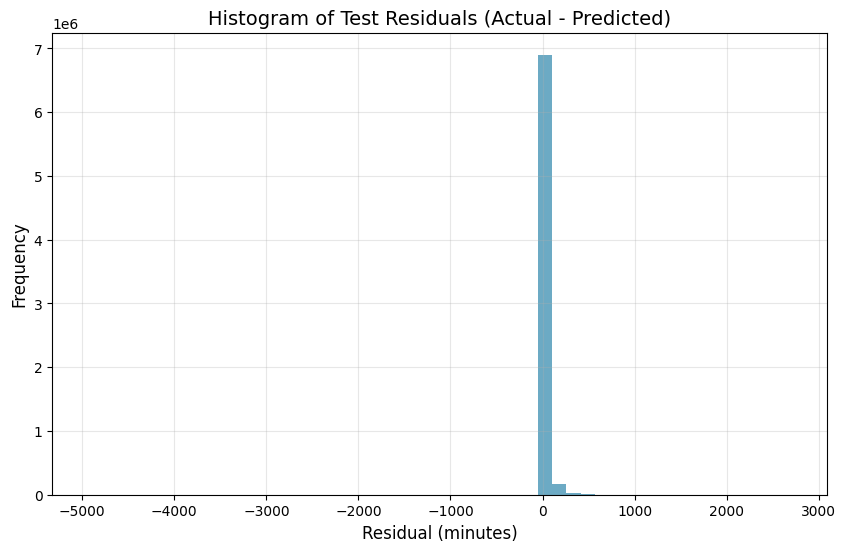

Min residual: -4944.2070
Max residual: 2708.7397
Max actuals: 2709.9995
Min actuals: 0.0000
Max predicted: 4944.2070
Min predicted: 0.0000


In [0]:
# Plot error distribution

import torch
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Load saved model
model_path = f"/dbfs/student-groups/Group_03_01/model/pytorch_mlp_raytune_2015_2018{add_to_path}_streaming.pth"
checkpoint = torch.load(model_path, map_location="cpu", weights_only=False)

# Recreate model architecture
embeddings_loaded, mlp_loaded, embedding_features_loaded = create_mlp_with_embeddings(
    dense_input_dim=checkpoint['dense_input_dim'],
    embedding_config=checkpoint['embedding_config'],
    hidden_dims=checkpoint['model_params']['hidden_dims'],
    dropout_rate=checkpoint['model_params']['dropout_rate']
)

# Load trained weights
embeddings_loaded.load_state_dict(checkpoint['embeddings_state_dict'])
mlp_loaded.load_state_dict(checkpoint['mlp_state_dict'])

print("Model loaded successfully!")

# Load test tensors
test_pickle_path = f"/dbfs/student-groups/Group_03_01/final_tensors{add_to_path_data}/test_2019.pkl"
with open(test_pickle_path, 'rb') as f:
    test_data = pickle.load(f)
X_test_dense = torch.FloatTensor(test_data['X_dense'])
X_test_embeddings = {k: torch.LongTensor(v) for k, v in test_data['X_embeddings'].items()}
y_test = torch.FloatTensor(test_data['y'])

# Move model to CPU
embeddings_loaded.eval()
mlp_loaded.eval()

# Prediction function
def forward_pass(embeddings, mlp, embedding_features, x_dense, x_embeddings):
    embedded_features = []
    for feat_name in embedding_features:
        emb = embeddings[feat_name](x_embeddings[feat_name])
        embedded_features.append(emb)
    if embedded_features:
        embeddings_concat = torch.cat(embedded_features, dim=1)
        x = torch.cat([x_dense, embeddings_concat], dim=1)
    else:
        x = x_dense
    return mlp(x)

# Batched prediction
batch_size = 4096
test_dataset = torch.utils.data.TensorDataset(X_test_dense, y_test)
test_indices = np.arange(len(X_test_dense))
test_preds = []
test_actuals = []

for i in range(0, len(test_indices), batch_size):
    idx = test_indices[i:i+batch_size]
    batch_dense = X_test_dense[idx]
    batch_embeddings = {k: v[idx] for k, v in X_test_embeddings.items()}
    with torch.no_grad():
        outputs = forward_pass(embeddings_loaded, mlp_loaded, embedding_features_loaded, batch_dense, batch_embeddings).squeeze()
    test_preds.append(outputs.cpu())
    test_actuals.append(y_test[idx].cpu())

test_preds_all = torch.cat(test_preds)
test_actuals_all = torch.cat(test_actuals)

# Convert residuals from log+1 space to original minutes
actuals_minutes = torch.expm1(test_actuals_all)
preds_minutes = torch.expm1(test_preds_all)
residuals = (actuals_minutes - preds_minutes).numpy()

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, color='#2E86AB', alpha=0.7)
plt.title("Histogram of Test Residuals (Actual - Predicted)", fontsize=14)
plt.xlabel("Residual (minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3)
display(plt.show())

print(f"Min residual: {residuals.min():.4f}")
print(f"Max residual: {residuals.max():.4f}")

print(f"Max actuals: {actuals_minutes.max():.4f}")
print(f"Min actuals: {actuals_minutes.min():.4f}")

print(f"Max predicted: {preds_minutes.max():.4f}")
print(f"Min predicted: {preds_minutes.min():.4f}")

In [0]:
# SHAP Visualization

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:473)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:750)
	at com.data